# Endpoint Conditional Ablation Study

This notebook investigates how much information about the evolutionary trajectory is encoded in the two endpoint sequences `S_start` (T=0) and `S_end` (T=β). It compares reconstruction accuracy of the intermediate segment `S_mid` under different conditioning strategies:
- **Unconditional arDCA** (conditioned only on `S_start`).
- **Conditional arDCA from T=0** (`predict_cond_start`): conditioned on `S_start` only.
- **Conditional arDCA from T=β** (`predict_cond_end`): conditioned on `S_end` only.

Accuracies are filtered by Conservation-Diversity Entropy (CDE) of the initial and final segments to separate low- and high-entropy regimes.

## Import Libraries

Load all required Python, PyTorch, and adabmDCA modules.

In [2]:
import sys
import gc
import os
import re
from pathlib import Path

sys.path.append("../../src/")

import torch
import torch.nn as nn
from torch import topk
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
import seaborn as sns

from adabmDCA.fasta import get_tokens, write_fasta, import_from_fasta, encode_sequence
from adabmDCA.utils import get_device, get_dtype
from adabmDCA.dataset import DatasetDCA
from adabmDCA.functional import one_hot
from adabmDCA.statmech import compute_energy
from adabmDCA.io import load_params

import arDCA_paths
from arDCA_paths import arDCA_paths

device = get_device("cpu")
device2 = get_device("cuda")
dtype = get_dtype("float32")

plt.rcParams.update({
    "text.usetex": True,
})

print("Libraries loaded successfully!")

Running on CPU
Running on NVIDIA RTX A4000
Libraries loaded successfully!


## Prediction Functions

Define sampling strategies for reconstructing the intermediate segment `S_mid`:
- `predict_naive`: direct-path heuristic.
- `predict`: standard autoregressive arDCA decoding.
- `predict_cond_start`: conditional decoding using `S_start` as prefix.
- `predict_cond_end`: conditional decoding using `S_end` as prefix.

In [3]:
def predict_naive(data):
    X = one_hot(data.clone(), num_classes=21).to(dtype=dtype)
    B, L, q = X.shape
    l = L // 3
    first, second = X[:, :l, :], X[:, l:2*l, :]
    third = first.clone()
    mask_equal = (first == second).all(dim=2)
    rand = torch.rand(B, l, device=X.device)
    mask_replace = (~mask_equal) & (rand >= 0.5)
    third[mask_replace] = second[mask_replace]
    X[:, 2*l:3*l, :] = third
    return X.argmax(dim=-1)

def predict(data, model, ML=False, beta=1, device="cpu"):
    with torch.no_grad():
        model.to(device)
        X = one_hot(data.clone(), num_classes=21).to(dtype=dtype).to(device)
        L = X.shape[1]
        l = model.L // 3
        for i in range(L - l, L):
            prob = model.forward(X[:, :i, :], beta=beta)
            sample = prob.argmax(dim=1) if ML else torch.multinomial(prob, num_samples=1).squeeze()
            X[:, i] = nn.functional.one_hot(sample, model.q).to(dtype=model.h.dtype)
        model.to("cpu")
        return X.argmax(dim=-1).to("cpu")


def predict_cond_start(data, model, ML=False, beta=1, device="cpu"):
    """Predict using arDCA by sequentially filling the last third of the sequence."""
    torch.no_grad()
    model.to(device)
    L = data.shape[1]
    l = L // 3
    X_end = one_hot(data, num_classes=21)[:, 2*l:, :].clone().to(dtype=dtype).to(device)
    X_use = one_hot(data, num_classes=21)[:, :2*l, :].clone().to(dtype=dtype).to(device)
    for i in range(l, 2*l):
        prob = model.forward(X_use[:, :i, :], beta=beta)
        sample = prob.argmax(dim=1) if ML else torch.multinomial(prob, num_samples=1).squeeze()
        X_use[:, i] = nn.functional.one_hot(sample, model.q).to(dtype=model.h.dtype)
    model.to("cpu")
    X = torch.cat((X_use[:, :l], X_end, X_use[:, l:]), dim=1)
    return X.argmax(dim=-1).to("cpu")

def predict_cond_end(data, model, ML=False, beta=1, device="cpu"):
    """Predict using arDCA by sequentially filling the last third of the sequence."""
    torch.no_grad()
    model.to(device)
    L = data.shape[1]
    l = L // 3
    X_start = one_hot(data, num_classes=21)[:, :l, :].clone().to(dtype=dtype).to(device)
    X_use = one_hot(data, num_classes=21)[:, l:, :].clone().to(dtype=dtype).to(device)
    for i in range(l, 2*l):
        prob = model.forward(X_use[:, :i, :], beta=beta)
        sample = prob.argmax(dim=1) if ML else torch.multinomial(prob, num_samples=1).squeeze()
        X_use[:, i] = nn.functional.one_hot(sample, model.q).to(dtype=model.h.dtype)
    model.to("cpu")
    X = torch.cat((X_start, X_use), dim=1)
    return X.argmax(dim=-1).to("cpu")

## Conservation-Diversity Entropy (CDE)

Implement `compute_CDE_full_batch_fast`, which computes per-position CDE scores for a batch of sequences using the bmDCA model. Processed in chunks to manage GPU memory.

In [4]:
def compute_CDE_full_batch_fast(sequences, model, device=device, dtype=dtype, chunk_size=150):
    with torch.no_grad():
        batch_size, L, q = sequences.shape
        CDE_full_batch = torch.zeros((batch_size, L), device=device, dtype=dtype)
        for start in range(0, batch_size, chunk_size):
            end = min(start + chunk_size, batch_size)
            sequences_chunk = sequences[start:end]
            chunk_batch_size = sequences_chunk.shape[0]
            model_device = {
                "bias": model["bias"].to(device),
                "coupling_matrix": model["coupling_matrix"].to(device)
            }
            sequence_indices = sequences_chunk.argmax(-1)
            base = sequence_indices.unsqueeze(1).expand(-1, L * q, -1).reshape(chunk_batch_size * L * q, L).clone().to(device)
            positions = torch.arange(L, device=device).repeat_interleave(q).repeat(chunk_batch_size)
            values = torch.arange(q, device=device, dtype=torch.int64).repeat(L).repeat(chunk_batch_size)
            base[torch.arange(chunk_batch_size * L * q, device=device), positions] = values
            dms_oh = one_hot(base, num_classes=q).to(dtype)
            energy_dms = compute_energy(dms_oh, model_device).view(chunk_batch_size, L, q)
            energy_dms -= energy_dms.min(dim=2, keepdim=True)[0]
            p_i = torch.exp(-energy_dms) / torch.exp(-energy_dms).sum(dim=2, keepdim=True)
            CDE_chunk = -torch.sum(p_i * torch.log2(p_i), dim=2)
            CDE_full_batch[start:end] = CDE_chunk.cpu()
            del base, positions, values, dms_oh, energy_dms, p_i
        del sequences
        gc.collect()
        torch.cuda.empty_cache()
    return CDE_full_batch.cpu()

## Data Loading

Select the protein family, configure paths, and load the test FASTA datasets for all timescales. Build one-hot representations.

In [5]:
protein_family = "PF00072"
# use_1cond = True
best = ""
patience = "patience5/"


if protein_family == "Chorismate Mutase":
    data_path = "../generated_data/CM"
    cde_path = "../generated_data/CM/full_cde_test"
    MSA_path = "../MSAs/CM_130530_MC.fasta"
    original_model_path = "../evolution_bmDCA_model/CM/params.dat"
    t = 0
    model_paths = f"../models_train_val/CM/{patience}"
    model_1cond_path = f"../models_train_val/CM/{patience}1cond/"

    reg = "rJ1e-3_rH1e-5" #long_run_rJ1e-3_rH1e-5
    output_path = f"../immagini_paper/CM/{patience}ablation/{best}_{reg}/"


elif protein_family == "PF00072":
    data_path = "../generated_data/PF00072"
    cde_path = "../generated_data/PF00072/full_cde_test"
    MSA_path = "../MSAs/PF00072.fasta"
    original_model_path = "../evolution_bmDCA_model/PF00072/params.dat"
    t = 0
    model_paths = f"../models_train_val/PF00072/{patience}"
    model_1cond_path = f"../models_train_val/PF00072/{patience}1cond/"
    reg = "rJ1e-3_rH1e-5" #long_run_rJ1e-3_rH1e-5
    output_path = f"../immagini_paper/PF00072/{patience}ablation/{best}_{reg}/"
    

elif protein_family == "betalactamase":
    data_path = "../generated_data/betalactamase"
    cde_path = "../generated_data/betalactamase/full_cde_test"
    MSA_path = "../MSAs/betalactamase_nodupl_natural_noflankgaps.fa"
    original_model_path = "../evolution_bmDCA_model/betalactamase/params.dat"
    t = 0
    model_paths = f"../models_train_val/betalactamase/{patience}"
    model_1cond_path = f"../models_train_val/betalactamase/{patience}1cond/"
    reg = "rJ1e-3_rH1e-5" #long_run_rJ1e-3_rH1e-5
    output_path = f"../immagini_paper/betalactamase/{patience}ablation/{best}_{reg}/"


else:
    raise ValueError(f"Unknown protein family: {protein_family}")


In [6]:
data_type = "ACDEFGHIKLMNPQRSTVWY-"
tokens = get_tokens(data_type)

timescales = ["10e1", "10e2", "10e3", "10e4", "10e5", "10e6"] 
n_seqs = 20_000

data_files = [
    f"{data_path}/10e1_test.fasta",
    f"{data_path}/10e2_test.fasta",
    f"{data_path}/10e3_test.fasta",
    f"{data_path}/10e4_test.fasta",
    f"{data_path}/10e5_test.fasta",
    f"{data_path}/10e6_test.fasta",
]

datasets = {}
for t, path in zip(timescales, data_files):
    ds = DatasetDCA(path_data=path, alphabet=data_type, device=device, dtype=dtype, no_reweighting=True)
    # indices = torch.randperm(ds.data.shape[0])[:n_seqs]
    datasets[t] = ds.data[:n_seqs]#.argmax(dim=-1) #[indices]
    del ds
    gc.collect()

print(f"Loaded {len(datasets)} datasets with {n_seqs} sequences each")

Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M_eff = 20000.
Multi-sequence alignment imported: M = 20000, L = 336, q = 21, M_eff = 20000.
Loaded 6 datasets with 20000 sequences each


In [7]:
datasets_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in datasets.items()
}

## Model Loading

Load the main arDCA models (one per timescale) for standard prediction, and the secondary conditional models (`models_2nd`) for `predict_cond_start` / `predict_cond_end`.

In [9]:
# Get dimensions
L = datasets[timescales[0]].shape[1] // 3
L2 = 2*L
L3 = L * 3
q = 21

# Load main models (for standard prediction)
models = {}
for t in timescales:
    path_params = model_paths + f"{t}_{reg}/params{best}.pth"
    params = torch.load(path_params, map_location='cpu')
    params['entropic_order'] = torch.arange(0, L3, dtype=torch.long, device='cpu')
    params['inverse_entropic_order'] = torch.arange(0, L3, dtype=torch.long, device='cpu')
    model = arDCA_paths(L=L3, q=q).to(device='cpu', dtype=dtype)
    model.load_state_dict(params, strict=False)
    models[t] = model

print(f"Loaded {len(models)} arDCA models")

original_model = load_params(original_model_path, tokens=tokens, device=device, dtype=dtype)

arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
Loaded 6 arDCA models


In [10]:
# if use_1cond:
# Load models_2nd (for conditional predictions T=0 and T=β)
models_2nd = {}
for t in timescales:
    path_params = model_1cond_path + f"{t}_{reg}/params{best}.pth" #f"{t}_rJ1e-4_rH1e-6_1condition/params.pth"
    params = torch.load(path_params, map_location='cpu')
    params['entropic_order'] = torch.arange(0, L2, dtype=torch.long, device='cpu')
    params['inverse_entropic_order'] = torch.arange(0, L2, dtype=torch.long, device='cpu')
    model_2nd = arDCA_paths(L=L2, q=q, model="second").to(device='cpu', dtype=dtype)
    model_2nd.load_state_dict(params, strict=False)
    models_2nd[t] = model_2nd



print(f"Loaded {len(models_2nd)} arDCA models_2nd for conditional predictions")

arDCA model initialized with second
arDCA model initialized with second
arDCA model initialized with second
arDCA model initialized with second
arDCA model initialized with second
arDCA model initialized with second
Loaded 6 arDCA models_2nd for conditional predictions


# Output Path

Create the output directory for saving figures and tables.

In [11]:
os.makedirs(output_path, exist_ok=True)
print(f"Output path created/verified: {output_path}")

Output path created/verified: ../immagini_paper/PF00072/patience5/ablation/_rJ1e-3_rH1e-5/


## Predictions

Generate reconstructions of the intermediate segment using each prediction strategy. Conditional predictions from T=0 and T=β are enabled when `use_1cond = True`.

In [12]:
# Generate predictions with different methods
print("Generating predictions...")
ML_flag = True

# Naive  prediction (β)
predicted_naive = {}
for t in timescales:
    print(f"  Timescale {t} - naive")
    predicted_naive[t] = predict_naive(datasets[t])


# Standard  prediction (β)
predicted = {}
for t in timescales:
    print(f"  Timescale {t} - prediction")
    predicted[t] = predict(datasets[t], models[t], ML=False, beta=1, device=device2)


# Standard ML prediction (β)
predictedML = {}
for t in timescales:
    print(f"  Timescale {t} - ML prediction")
    predictedML[t] = predict(datasets[t], models[t], ML=ML_flag, beta=1, device=device2)



Generating predictions...
  Timescale 10e1 - naive
  Timescale 10e2 - naive
  Timescale 10e3 - naive
  Timescale 10e4 - naive
  Timescale 10e5 - naive
  Timescale 10e6 - naive
  Timescale 10e1 - prediction
  Timescale 10e2 - prediction
  Timescale 10e3 - prediction
  Timescale 10e4 - prediction
  Timescale 10e5 - prediction
  Timescale 10e6 - prediction
  Timescale 10e1 - ML prediction
  Timescale 10e2 - ML prediction
  Timescale 10e3 - ML prediction
  Timescale 10e4 - ML prediction
  Timescale 10e5 - ML prediction
  Timescale 10e6 - ML prediction


In [13]:
# if use_1cond:
# Conditional predictions with T=0 (using models_2nd)
predicted_0 = {}
for t in timescales:
    print(f"  Timescale {t} - t=0 prediction (start)")
    predicted_0[t] = predict_cond_start(datasets[t], models_2nd[t], ML=ML_flag, beta=1, device=device2)

# Conditional predictions with T=β (using models_2nd)
predicted_T = {}
for t in timescales:
    print(f"  Timescale {t} - t=T prediction (end)")
    predicted_T[t] = predict_cond_end(datasets[t], models_2nd[t], ML=ML_flag, beta=1, device=device2)

print("Predictions complete!")

  Timescale 10e1 - t=0 prediction (start)
  Timescale 10e2 - t=0 prediction (start)
  Timescale 10e3 - t=0 prediction (start)
  Timescale 10e4 - t=0 prediction (start)
  Timescale 10e5 - t=0 prediction (start)
  Timescale 10e6 - t=0 prediction (start)
  Timescale 10e1 - t=T prediction (end)
  Timescale 10e2 - t=T prediction (end)
  Timescale 10e3 - t=T prediction (end)
  Timescale 10e4 - t=T prediction (end)
  Timescale 10e5 - t=T prediction (end)
  Timescale 10e6 - t=T prediction (end)
Predictions complete!


## One-Hot Encoding

Convert all predicted sequences to one-hot format for downstream accuracy and energy computation.

In [14]:
# predictednNaive_oh = {
#     key: one_hot(data, num_classes=21).to(dtype=dtype)
#     for key, data in predicted_naive.items()
# }

# predicted_oh = {
#     key: one_hot(data, num_classes=21).to(dtype=dtype)
#     for key, data in predicted.items()
# }

# predictedML_oh = {
#     key: one_hot(data, num_classes=21).to(dtype=dtype)
#     for key, data in predictedML.items()
# }

predictedML_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in predictedML.items()
}

In [15]:
# if use_1cond:
predicted0_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in predicted_0.items()
}

predictedT_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in predicted_T.items()
}

print("One-hot encoding complete!")

One-hot encoding complete!


## CDE Values

Load precomputed CDE arrays for the initial and final segments from disk. These are used to stratify sequences by evolutionary constraint.

In [16]:
def load_cde_dict(path, datasets=datasets, timescales=timescales, dtype=dtype):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"CDE file not found: {path}")
    loaded = np.load(path, allow_pickle=True).item()
    missing = [key for key in timescales if key not in loaded]
    if missing:
        raise KeyError(f"Missing timescales in {path}: {missing}")

    cde = {}
    for key in timescales:
        n_values = datasets[key].shape[0]
        values = loaded[key]
        if values.shape[0] < n_values:
            raise ValueError(
                f"CDE file {path} for {key} has only {values.shape[0]} values, "
                f"but dataset has {n_values} sequences."
            )
        cde[key] = torch.as_tensor(values[:n_values], dtype=dtype)
    return cde


# if use_1cond:

L = datasets[timescales[0]].shape[1] // 3

cde_path = Path(cde_path)
CDE_0 = load_cde_dict(cde_path / "CDE_0.npy")
CDE_0_mean = load_cde_dict(cde_path / "CDE_0_mean.npy")

CDE_T = load_cde_dict(cde_path / "CDE_T.npy")
CDE_T_mean = load_cde_dict(cde_path / "CDE_T_mean.npy")

# Original CDE computation kept for reference. Prefer loading precomputed
# CDE arrays above so the notebook does not recompute them every run.
# CDE_0 = {key: compute_CDE_full_batch_fast(datasets_oh[key][:, :L], original_model, device=device2, dtype=dtype, chunk_size=200)  for key in timescales}
# CDE_0_mean = {key: CDE_0[key].mean(dim=1) for key in timescales}

# CDE_T = {key: compute_CDE_full_batch_fast(datasets_oh[key][:, L:2*L], original_model, device=device2, dtype=dtype, chunk_size=200)  for key in timescales}
# CDE_T_mean = {key: CDE_T[key].mean(dim=1) for key in timescales}


## Accuracy

Compute per-sequence reconstruction accuracy for each prediction method across all timescales.

In [17]:
def compute_accuracy(data, prediction):
    l = data.shape[1] // 3
    third = data[:, 2*l:3*l, :].argmax(dim=-1)
    third_pred = prediction[:, 2*l:3*l, :].argmax(dim=-1)
    return (third == third_pred).float().sum(dim=-1) / l

acc_mdlML = {key: compute_accuracy(datasets_oh[key], predictedML_oh[key]) for key in timescales}



In [18]:
# if use_1cond:

acc0_ML = {key: compute_accuracy(datasets_oh[key], predicted0_oh[key]) for key in timescales}
accT_ML = {key: compute_accuracy(datasets_oh[key], predictedT_oh[key]) for key in timescales}

print("Accuracy computations complete!")

Accuracy computations complete!


## Accuracy by CDE Filter and Timescale

Split sequences by CDE regime (low/high for initial and final segments) and plot mean accuracy per method, timescale, and CDE quadrant.

Distribuzione CDE_0_mean:
  40° percentile: 2.3468
  60° percentile: 2.4699
  Range interquartile (IQR): 0.1231
  Min: 1.7159
  Max: 2.8298
  Media: 2.3937
  Mediana (50° percentile): 2.4104


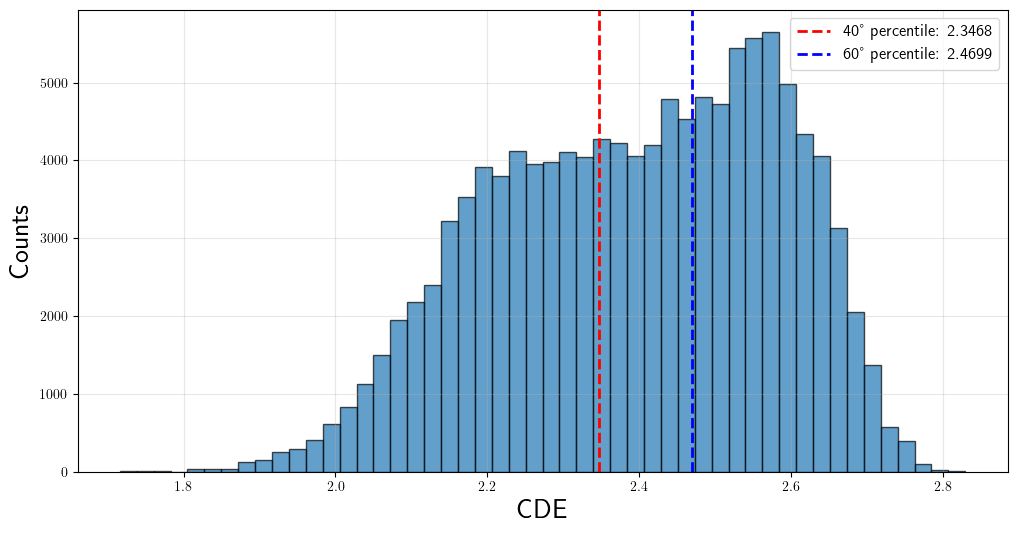

In [19]:
# if use_1cond:

CDE_0_mean_tot = torch.cat([CDE_0_mean[t] for t in timescales])

# Compute 25th and 75th percentiles
percentile = 0.4
percentile_low = torch.quantile(CDE_0_mean_tot, percentile).item()
percentile_high = torch.quantile(CDE_0_mean_tot, 1 - percentile).item()

print(f"Distribuzione CDE_0_mean:")
print(f"  {int(percentile*100)}° percentile: {percentile_low:.4f}")
print(f"  {int((1-percentile)*100)}° percentile: {percentile_high:.4f}")
print(f"  Range interquartile (IQR): {percentile_high - percentile_low:.4f}")
print(f"  Min: {CDE_0_mean_tot.min():.4f}")
print(f"  Max: {CDE_0_mean_tot.max():.4f}")
print(f"  Media: {CDE_0_mean_tot.mean():.4f}")
print(f"  Mediana (50° percentile): {torch.quantile(CDE_0_mean_tot, 0.5).item():.4f}")

# Plot histogram with percentile lines
plt.figure(figsize=(12, 6))
plt.hist(CDE_0_mean_tot.cpu().numpy(), bins=50, edgecolor='black', alpha=0.7)
plt.axvline(percentile_low, color='red', linestyle='--', linewidth=2, label=f'{int(percentile*100)}° percentile: {percentile_low:.4f}')
plt.axvline(percentile_high, color='blue', linestyle='--', linewidth=2, label=f'{int((1-percentile)*100)}° percentile: {percentile_high:.4f}')
plt.xlabel('CDE', fontsize=20)
plt.ylabel('Counts', fontsize=20)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_path, "CDE_mean_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

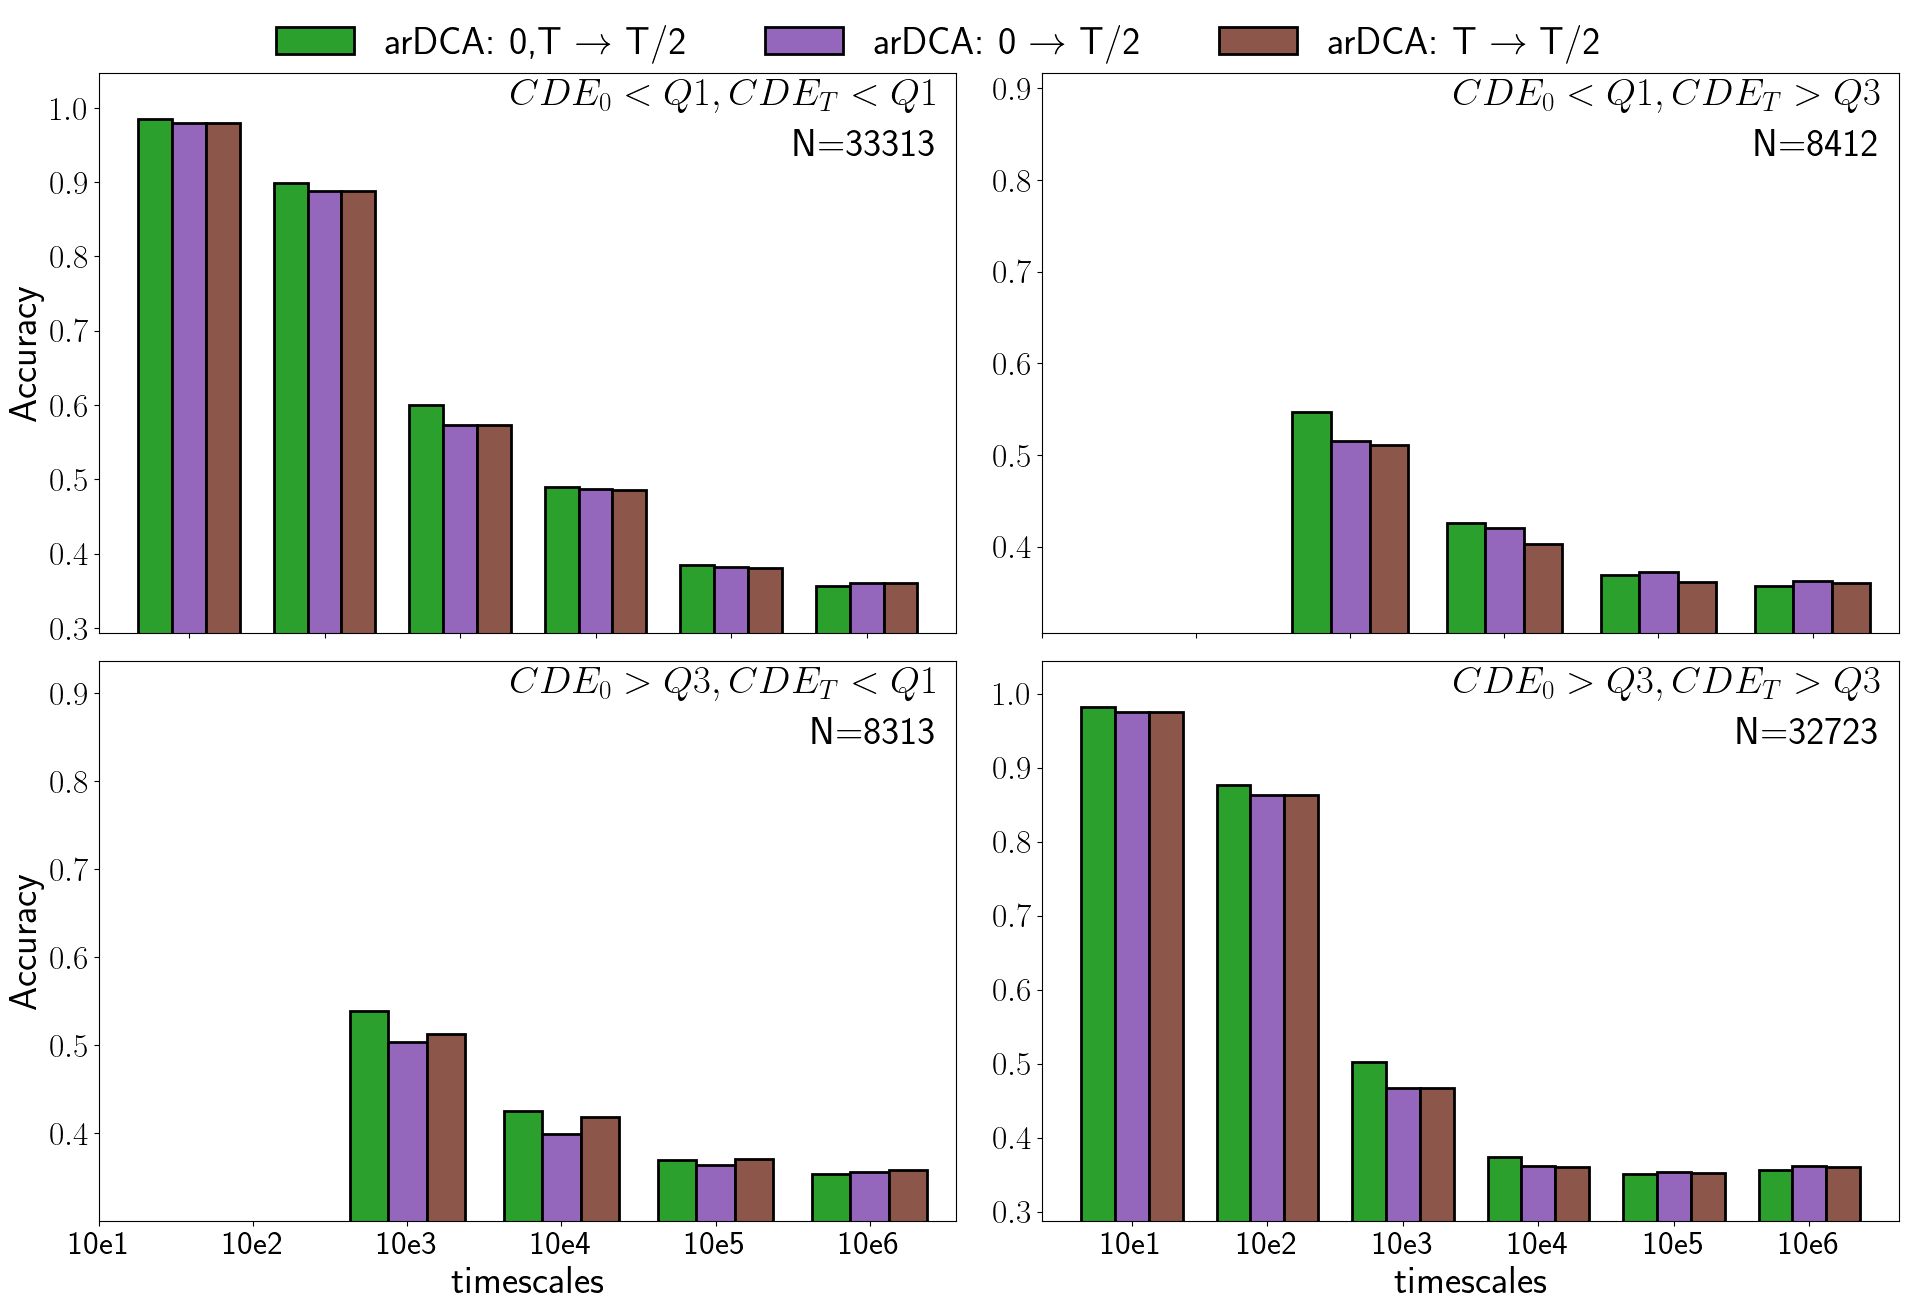


Summary of mean accuracies by filter and timescale:

1. $CDE_0 < 2.3467824459075928, CDE_T < 2.3467824459075928$
   Timescale 10e1:
      arDCA: 0,T $\rightarrow$ T/2: 0.9844 (N=7831)
      arDCA: 0 $\rightarrow$ T/2: 0.9796 (N=7831)
      arDCA: T $\rightarrow$ T/2: 0.9794 (N=7831)
   Timescale 10e2:
      arDCA: 0,T $\rightarrow$ T/2: 0.8989 (N=7478)
      arDCA: 0 $\rightarrow$ T/2: 0.8882 (N=7478)
      arDCA: T $\rightarrow$ T/2: 0.8877 (N=7478)
   Timescale 10e3:
      arDCA: 0,T $\rightarrow$ T/2: 0.6006 (N=6684)
      arDCA: 0 $\rightarrow$ T/2: 0.5733 (N=6684)
      arDCA: T $\rightarrow$ T/2: 0.5731 (N=6684)
   Timescale 10e4:
      arDCA: 0,T $\rightarrow$ T/2: 0.4899 (N=4825)
      arDCA: 0 $\rightarrow$ T/2: 0.4866 (N=4825)
      arDCA: T $\rightarrow$ T/2: 0.4862 (N=4825)
   Timescale 10e5:
      arDCA: 0,T $\rightarrow$ T/2: 0.3848 (N=3330)
      arDCA: 0 $\rightarrow$ T/2: 0.3813 (N=3330)
      arDCA: T $\rightarrow$ T/2: 0.3809 (N=3330)
   Timescale 10e6:
      arDCA:

In [20]:
# if use_1cond:

# Create simplified version with mean bars for each method and timescale
# Using same filters as cell 57
cde_low = percentile_low
cde_high = percentile_high

# Define the 4 filters
filters = [
    {'name': fr'$CDE_0 < {cde_low}, CDE_T < {cde_low}$', 
    'condition': lambda t: (CDE_0_mean[t] < cde_low) & (CDE_T_mean[t] < cde_low)},
    {'name': fr'$CDE_0 < {cde_low}, CDE_T > {cde_high}$', 
    'condition': lambda t: (CDE_0_mean[t] < cde_low) & (CDE_T_mean[t] > cde_high)},
    {'name': fr'$CDE_0 > {cde_high}, CDE_T < {cde_low}$', 
    'condition': lambda t: (CDE_0_mean[t] > cde_high) & (CDE_T_mean[t] < cde_low)},
    {'name': fr'$CDE_0 > {cde_high}, CDE_T > {cde_high}$', 
    'condition': lambda t: (CDE_0_mean[t] > cde_high) & (CDE_T_mean[t] > cde_high)},
]

# Method configurations
methods = [
    {'name': 'acc_mdlML', 'label': r'arDCA: 0,T $\rightarrow$ T/2', 'color': 'C2'},  # Green
    {'name': 'acc0_ML', 'label': r'arDCA: 0 $\rightarrow$ T/2', 'color': 'C4'},  # Dark gray
    {'name': 'accT_ML', 'label': r'arDCA: T $\rightarrow$ T/2', 'color': 'C5'},  # Light gray
]

# Create figure with 2x2 subplots with minimal spacing
fig, axes = plt.subplots(2, 2, figsize=(24, 14))
axes = axes.flatten()

# Add main title
# fig.suptitle('Mean Accuracy', fontsize=32, fontweight='bold', y=0.98)

# Collect all data
all_filter_data = []

for filter_idx, filter_info in enumerate(filters):
    filter_all_means = []
    for method in methods:
        method_means = []
        method_data = eval(method['name'])
        
        for t in timescales:
            mask = filter_info['condition'](t)
            values = method_data[t][mask]
            
            if len(values) > 0:
                mean_val = np.mean(values.cpu().numpy())
            else:
                mean_val = 0
            method_means.append(mean_val)
        
        filter_all_means.append(method_means)
    all_filter_data.append(filter_all_means)

# Create filter labels from conditions
filter_labels = [
    fr'$CDE_0 < Q1, CDE_T < Q1$',
    fr'$CDE_0 < Q1, CDE_T > Q3$',
    fr'$CDE_0 > Q3, CDE_T < Q1$',
    fr'$CDE_0 > Q3, CDE_T > Q3$'
    ]

# Process each filter with collected data
for filter_idx, filter_info in enumerate(filters):
    ax = axes[filter_idx]
    all_means = all_filter_data[filter_idx]
    
    # Prepare data structure: for each timescale, collect means for each method
    n_timescales = len(timescales)
    n_methods = len(methods)
    
    # Bar width and positions
    bar_width = 0.25
    x_positions = np.arange(n_timescales)
    
    # Find min and max for this subplot
    subplot_min = 1.0
    subplot_max = 0.0
    for means in all_means:
        for mean_val in means:
            if mean_val > 0:  # Only consider valid data
                subplot_min = min(subplot_min, mean_val)
                subplot_max = max(subplot_max, mean_val)
    
    # Plot bars for each method (only if at least 50 samples available per timescale)
    handles = []
    for method_idx, (method, means) in enumerate(zip(methods, all_means)):
        offset = (method_idx - 1) * bar_width  # Center the groups
        
        # Filter: plot only if at least 50 sequences satisfy this condition
        filtered_means = []
        filtered_x_positions = []
        for ts_idx, t in enumerate(timescales):
            mask = filter_info['condition'](t)
            n_seqs = sum(mask.cpu().numpy())
            if n_seqs >= 50:
                filtered_means.append(means[ts_idx])
                filtered_x_positions.append(x_positions[ts_idx])
            else:
                filtered_means.append(0)  # Placeholder per mantenere l'allineamento
                filtered_x_positions.append(x_positions[ts_idx])
        
        # Plot only bars with at least 50 samples
        bars_list = []
        for x_pos, mean_val, ts_idx, t in zip(filtered_x_positions, filtered_means, range(len(timescales)), timescales):
            mask = filter_info['condition'](t)
            n_seqs = sum(mask.cpu().numpy())
            if n_seqs >= 50 and mean_val > 0:
                bar = ax.bar(x_pos + offset, mean_val, bar_width, 
                        color=method['color'], 
                        edgecolor='black', linewidth=2)
                if len(bars_list) == 0:
                    bars_list.append(bar)
        
        if len(bars_list) > 0:
            handles.append(bars_list[0])
        else:
            # Crea una barra vuota per la legenda
            handles.append(ax.bar([], [], bar_width, label=method['label'], 
                                color=method['color'], edgecolor='black', linewidth=2))
        
        # # Add value labels on top of bars
        # for bar, mean_val in zip(bars, means):
        #     height = bar.get_height()
        #     if height > 0:  # Only show label if there's data
        #         ax.text(bar.get_x() + bar.get_width()/2., height,
        #                f'{mean_val:.2f}',
        #                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Count total sequences in this filter
    total_seqs = sum([sum(filter_info['condition'](t).cpu().numpy()) for t in timescales])
    
    # Add N=... text in upper left corner
    ax.text(0.98, 0.90, f'N={total_seqs}', transform=ax.transAxes,
        fontsize=28, fontweight='bold', va='top', ha='right')
    ax.text(0.98, 0.99, filter_labels[filter_idx], transform=ax.transAxes,
        fontsize=28, fontweight='bold', va='top', ha='right')
    
    # Set ylabel only for left column (filter_idx 0 and 2)
    if filter_idx in [0, 2]:
        ax.set_ylabel('Accuracy', fontsize=28, fontweight='bold')
    
    ax.set_xticks(x_positions)
    
    # Set xlabel only for bottom row (filter_idx 2 and 3)
    if filter_idx in [2, 3]:
        ax.set_xticklabels(timescales, fontsize=20)
        ax.set_xlabel("timescales", fontsize=28, fontweight='bold')
    else:
        ax.set_xticklabels([])
    
    # Set y limits per subplot with some margin
    y_margin = (subplot_max - subplot_min) * 0.1
    ax.set_ylim([subplot_min - y_margin, subplot_max + y_margin])
    # ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=24)

# Create single legend with correct colors from methods
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=method['color'], edgecolor='black', linewidth=2, label=method['label']) 
                for method in methods]
fig.legend(handles=legend_elements, 
        loc='center', bbox_to_anchor=(0.5, 0.95), 
        ncol=3, fontsize=28, frameon=False, fancybox=False, shadow=False)

# Adjust layout to minimize spacing and make room for legend
plt.subplots_adjust(hspace=0.05, wspace=0.1, top=0.93, left=0.15)
plt.savefig(os.path.join(output_path, 'ablation_study.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nSummary of mean accuracies by filter and timescale:\n")
for filter_idx, filter_info in enumerate(filters):
    print(f"{filter_idx + 1}. {filter_info['name']}")
    for t in timescales:
        print(f"   Timescale {t}:")
        for method in methods:
            method_data = eval(method['name'])
            mask = filter_info['condition'](t)
            values = method_data[t][mask]
            if len(values) > 0:
                mean_val = np.mean(values.cpu().numpy())
                n_seqs = len(values)
                print(f"      {method['label']}: {mean_val:.4f} (N={n_seqs})")
            else:
                print(f"      {method['label']}: No data")


In [21]:
# if use_1cond:

# Create summary tables for the second quadrant (CDE_0 < Q1, CDE_T > Q3)
# third quadrant (CDE_0 > Q3, CDE_T < Q1) from cell 22
import pandas as pd

# Method configurations (same as cell 22)
methods = [
    {'name': 'acc_mdlML', 'label': r'arDCA: 0,T → T/2'},
    {'name': 'acc0_ML', 'label': r'arDCA: 0 → T/2'},
    {'name': 'accT_ML', 'label': r'arDCA: T → T/2'},
]

# Define the filters for second and third quadrants
# Second quadrant (index 1): CDE_0 < Q1, CDE_T > Q3
# Third quadrant (index 2): CDE_0 > Q3, CDE_T < Q1
filters_selected = [
    {'name': fr'CDE_0 < Q1, CDE_T > Q3', 
    'condition': lambda t: (CDE_0_mean[t] < percentile_low) & (CDE_T_mean[t] > percentile_high)},
    {'name': fr'CDE_0 > Q3, CDE_T < Q1', 
    'condition': lambda t: (CDE_0_mean[t] > percentile_high) & (CDE_T_mean[t] < percentile_low)},
]

# Process each filter
for filter_idx, filter_info in enumerate(filters_selected):
    print("\n" + "="*100)
    print(f"{'SECOND QUADRANT' if filter_idx == 0 else 'THIRD QUADRANT'}: {filter_info['name']}")
    print("="*100)
    
    # Collect data for table
    table_data = []
    
    for method in methods:
        method_data = eval(method['name'])
        row = {'Method': method['label']}
        
        for t in timescales:
            mask = filter_info['condition'](t)
            values = method_data[t][mask]
            
            if len(values) > 0:
                mean_val = np.mean(values.cpu().numpy())
                n_seqs = len(values)
                row[f'{t}'] = f'{mean_val:.4f} (N={n_seqs})'
            else:
                row[f'{t}'] = 'No data'
        
        table_data.append(row)
    
    # Build DataFrame
    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))
    
    # Save table in the output folder
    quadrant_name = 'second_quadrant' if filter_idx == 0 else 'third_quadrant'
    table_csv_path = Path(output_path) / f'summary_table_{quadrant_name}.csv'
    table_txt_path = Path(output_path) / f'summary_table_{quadrant_name}.txt'
    df.to_csv(table_csv_path, index=False)
    with open(table_txt_path, 'w', encoding='utf-8') as f:
        f.write(df.to_string(index=False))
        f.write('\n')
    print(f"Saved table to: {table_csv_path}")
    print(f"Saved table to: {table_txt_path}")
    
    # Print total sequences
    total_seqs = sum([sum(filter_info['condition'](t).cpu().numpy()) for t in timescales])
    print("="*100)
    print(f"Total sequences across all timescales: N={total_seqs}")
    print("="*100)


SECOND QUADRANT: CDE_0 < Q1, CDE_T > Q3
          Method    10e1         10e2           10e3            10e4            10e5            10e6
arDCA: 0,T → T/2 No data 0.8661 (N=2) 0.5474 (N=271) 0.4260 (N=1714) 0.3688 (N=3172) 0.3569 (N=3253)
  arDCA: 0 → T/2 No data 0.8482 (N=2) 0.5152 (N=271) 0.4206 (N=1714) 0.3723 (N=3172) 0.3625 (N=3253)
  arDCA: T → T/2 No data 0.8661 (N=2) 0.5103 (N=271) 0.4028 (N=1714) 0.3616 (N=3172) 0.3601 (N=3253)
Saved table to: ../immagini_paper/PF00072/patience5/ablation/_rJ1e-3_rH1e-5/summary_table_second_quadrant.csv
Saved table to: ../immagini_paper/PF00072/patience5/ablation/_rJ1e-3_rH1e-5/summary_table_second_quadrant.txt
Total sequences across all timescales: N=8412

THIRD QUADRANT: CDE_0 > Q3, CDE_T < Q1
          Method    10e1         10e2           10e3            10e4            10e5            10e6
arDCA: 0,T → T/2 No data 0.8839 (N=1) 0.5390 (N=303) 0.4251 (N=1680) 0.3703 (N=3225) 0.3538 (N=3104)
  arDCA: 0 → T/2 No data 0.8661 (N=1) 0.5037 (N

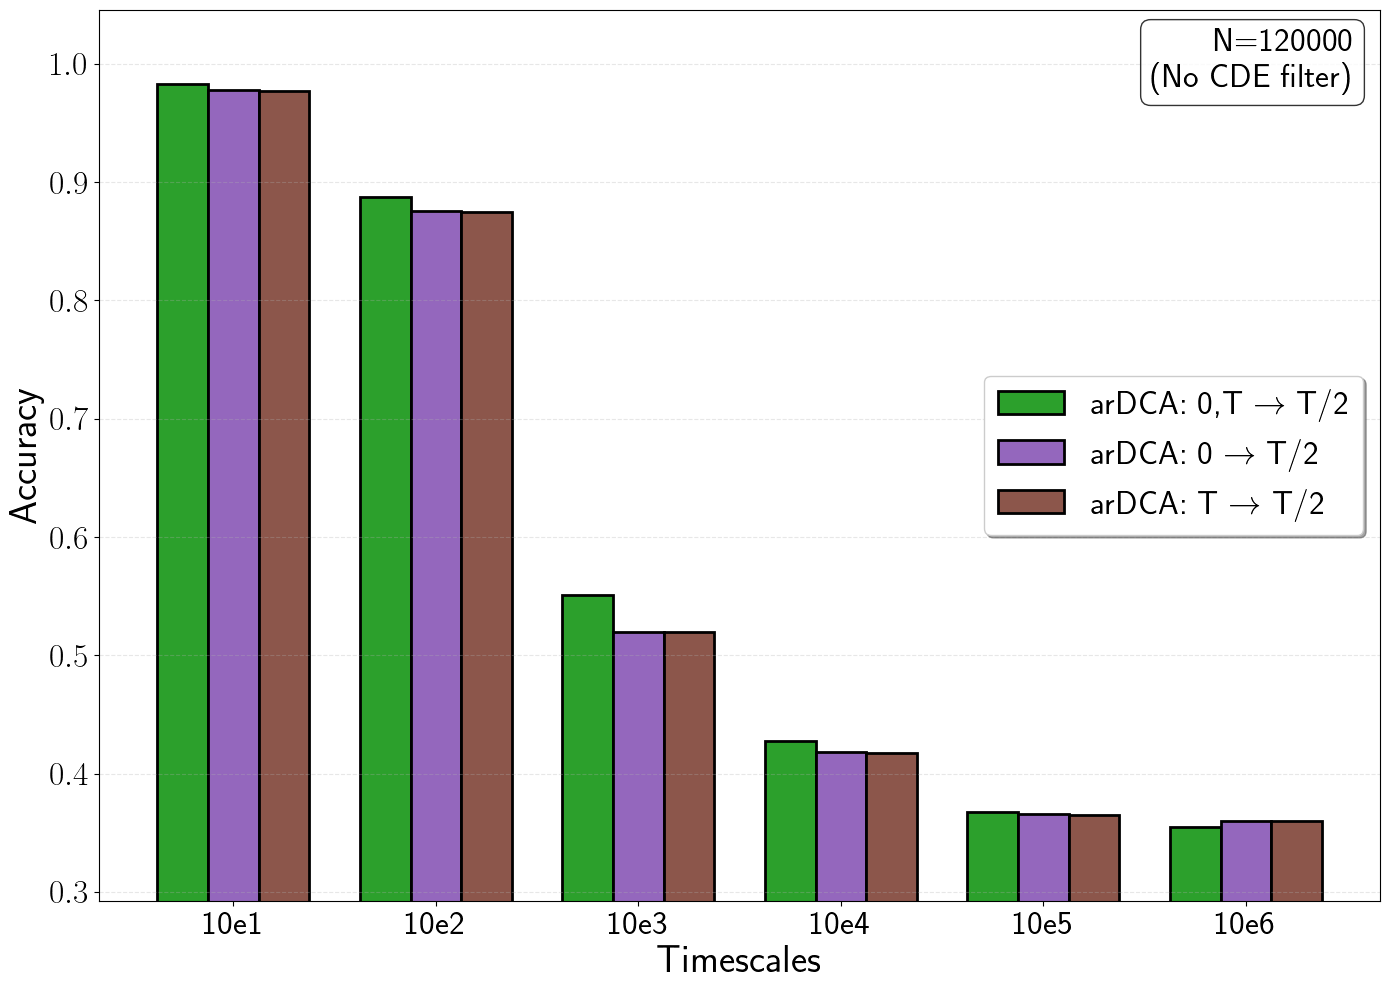


Summary of mean accuracies by method and timescale (NO CDE filtering):

Timescale 10e1:
   arDCA: 0,T $\rightarrow$ T/2: 0.9827 (N=20000)
   arDCA: 0 $\rightarrow$ T/2: 0.9775 (N=20000)
   arDCA: T $\rightarrow$ T/2: 0.9774 (N=20000)

Timescale 10e2:
   arDCA: 0,T $\rightarrow$ T/2: 0.8871 (N=20000)
   arDCA: 0 $\rightarrow$ T/2: 0.8751 (N=20000)
   arDCA: T $\rightarrow$ T/2: 0.8749 (N=20000)

Timescale 10e3:
   arDCA: 0,T $\rightarrow$ T/2: 0.5507 (N=20000)
   arDCA: 0 $\rightarrow$ T/2: 0.5193 (N=20000)
   arDCA: T $\rightarrow$ T/2: 0.5196 (N=20000)

Timescale 10e4:
   arDCA: 0,T $\rightarrow$ T/2: 0.4279 (N=20000)
   arDCA: 0 $\rightarrow$ T/2: 0.4180 (N=20000)
   arDCA: T $\rightarrow$ T/2: 0.4178 (N=20000)

Timescale 10e5:
   arDCA: 0,T $\rightarrow$ T/2: 0.3673 (N=20000)
   arDCA: 0 $\rightarrow$ T/2: 0.3658 (N=20000)
   arDCA: T $\rightarrow$ T/2: 0.3652 (N=20000)

Timescale 10e6:
   arDCA: 0,T $\rightarrow$ T/2: 0.3552 (N=20000)
   arDCA: 0 $\rightarrow$ T/2: 0.3598 (N=20000

In [22]:
# if use_1cond:

# Unified plot: all methods and timescales in a single subplot (NO CDE filtering)

# Method configurations
methods = [
    {'name': 'acc_mdlML', 'label': r'arDCA: 0,T $\rightarrow$ T/2', 'color': 'C2'},  # Green
    {'name': 'acc0_ML', 'label': r'arDCA: 0 $\rightarrow$ T/2', 'color': 'C4'},  # Dark gray
    {'name': 'accT_ML', 'label': r'arDCA: T $\rightarrow$ T/2', 'color': 'C5'},  # Light gray
]

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Collect all means for all methods across timescales (NO filtering)
all_means = []
for method in methods:
    method_means = []
    method_data = eval(method['name'])
    
    for t in timescales:
        # NO CDE filtering - use all data
        values = method_data[t]
        mean_val = np.mean(values.cpu().numpy())
        method_means.append(mean_val)
    
    all_means.append(method_means)

# Prepare data structure: for each timescale, collect means for each method
n_timescales = len(timescales)
n_methods = len(methods)

# Bar width and positions
bar_width = 0.25
x_positions = np.arange(n_timescales)

# Find min and max for y-axis
subplot_min = 1.0
subplot_max = 0.0
for means in all_means:
    for mean_val in means:
        subplot_min = min(subplot_min, mean_val)
        subplot_max = max(subplot_max, mean_val)

# Plot bars for each method
handles = []
for method_idx, (method, means) in enumerate(zip(methods, all_means)):
    offset = (method_idx - 1) * bar_width  # Center the groups
    
    bars = ax.bar(x_positions + offset, means, bar_width, 
                color=method['color'], 
                edgecolor='black', linewidth=2,
                label=method['label'])
    handles.append(bars)

# Count total sequences (all sequences, no filtering)
total_seqs = sum([len(eval(methods[0]['name'])[t]) for t in timescales])

# Add N=... annotation in upper-right corner
ax.text(0.98, 0.98, f'N={total_seqs}\n(No CDE filter)', transform=ax.transAxes,
    fontsize=24, fontweight='bold', va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Labels and formatting
ax.set_ylabel('Accuracy', fontsize=28, fontweight='bold')
ax.set_xlabel('Timescales', fontsize=28, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels(timescales, fontsize=24)

# Set y limits with some margin
y_margin = (subplot_max - subplot_min) * 0.1
ax.set_ylim([subplot_min - y_margin, subplot_max + y_margin])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=24)

# Add legend
ax.legend(fontsize=24, loc='best', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'ablation_study_no_filter.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nSummary of mean accuracies by method and timescale (NO CDE filtering):\n")
for t in timescales:
    print(f"Timescale {t}:")
    for method in methods:
        method_data = eval(method['name'])
        values = method_data[t]
        mean_val = np.mean(values.cpu().numpy())
        n_seqs = len(values)
        print(f"   {method['label']}: {mean_val:.4f} (N={n_seqs})")
    print()

In [23]:
# if use_1cond:

# Create a summary table with results from the previous plot
import pandas as pd

# Method configurations (same as previous cell)
methods = [
    {'name': 'acc_mdlML', 'label': r'arDCA: 0,T → T/2'},
    {'name': 'acc0_ML', 'label': r'arDCA: 0 → T/2'},
    {'name': 'accT_ML', 'label': r'arDCA: T → T/2'},
]

# Collect data for table
table_data = []

for method in methods:
    method_data = eval(method['name'])
    row = {'Method': method['label']}
    
    for t in timescales:
        values = method_data[t]
        mean_val = np.mean(values.cpu().numpy())
        n_seqs = len(values)
        
        # Add both mean accuracy and number of sequences
        row[f'{t}'] = f'{mean_val:.4f}'
    
    table_data.append(row)

# Create DataFrame
df = pd.DataFrame(table_data)

print("\n" + "="*100)
print("SUMMARY TABLE: Mean Accuracy by Method and Timescale (No CDE filtering)")
print("="*100)
print(df.to_string(index=False))

# Save table in the output folder
table_csv_path = Path(output_path) / 'summary_table_no_cde_filter.csv'
table_txt_path = Path(output_path) / 'summary_table_no_cde_filter.txt'
df.to_csv(table_csv_path, index=False)
with open(table_txt_path, 'w', encoding='utf-8') as f:
    f.write(df.to_string(index=False))
    f.write('\n')
print(f"Saved table to: {table_csv_path}")
print(f"Saved table to: {table_txt_path}")

print("="*100)
print(f"\nNote: Each timescale has N=15000 sequences")
print(f"Total sequences: N={len(timescales) * 15000}")
print("="*100)


SUMMARY TABLE: Mean Accuracy by Method and Timescale (No CDE filtering)
          Method   10e1   10e2   10e3   10e4   10e5   10e6
arDCA: 0,T → T/2 0.9827 0.8871 0.5507 0.4279 0.3673 0.3552
  arDCA: 0 → T/2 0.9775 0.8751 0.5193 0.4180 0.3658 0.3598
  arDCA: T → T/2 0.9774 0.8749 0.5196 0.4178 0.3652 0.3596
Saved table to: ../immagini_paper/PF00072/patience5/ablation/_rJ1e-3_rH1e-5/summary_table_no_cde_filter.csv
Saved table to: ../immagini_paper/PF00072/patience5/ablation/_rJ1e-3_rH1e-5/summary_table_no_cde_filter.txt

Note: Each timescale has N=15000 sequences
Total sequences: N=90000


In [24]:
# if use_1cond:
#     raise SystemExit("Notebook stopped before clustering because use_1cond=True.")

# Clustering Analysis

Cluster the natural MSA using KMeans and assign each test sequence to a cluster based on its first segment. This allows analysing whether sequences that cross cluster boundaries (in the intermediate segment) are harder to reconstruct.

In [25]:
cluster_temperature = 1.0

### Load Natural MSA for Clustering

Load the natural MSA and convert to one-hot format for use as KMeans cluster reference.

In [26]:
headers, msa_enc_nat = import_from_fasta(MSA_path, tokens=tokens, filter_sequences=True)
msa_oh_nat = one_hot(torch.tensor(msa_enc_nat, device=device, dtype=torch.int32), num_classes=q).to(dtype)


# Flatten msa_oh_nat to 2D for clustering
# msa_oh_nat has shape (n_sequences, L_nat, q_nat)
# Flatten to (n_sequences, L_nat * q_nat)
msa_flat = msa_oh_nat.cpu().numpy().reshape(msa_oh_nat.shape[0], -1)

Unknown token found: removing sequence A0A164QL65/1103-1214


In [27]:
# Load the top-3 KMeans models saved by the clustering notebook for the selected protein family
import pickle

clustering_dir = Path("clustering") / protein_family.replace(" ", "_")
kmeans_pkl_path = clustering_dir / "models_and_metadata_top3k.pkl"
print(f"Attempting to load KMeans models from: {kmeans_pkl_path}")
if not kmeans_pkl_path.exists():
    raise FileNotFoundError(
        f"KMeans model file not found: {kmeans_pkl_path}. Run clustering notebook first for {protein_family}."
    )

with open(kmeans_pkl_path, "rb") as f:
    clustering_payload = pickle.load(f)

if "kmeans_models" not in clustering_payload:
    raise KeyError(f"'kmeans_models' not found inside {kmeans_pkl_path}")

kmeans_models_loaded = clustering_payload["kmeans_models"]
if len(kmeans_models_loaded) == 0:
    raise ValueError(f"No KMeans models found in {kmeans_pkl_path}")

k_values_loaded = sorted([int(k) for k in kmeans_models_loaded.keys()])
kmeans_models_loaded = {int(k): v for k, v in kmeans_models_loaded.items()}

cluster_centers_by_k = {k: kmeans_models_loaded[k].cluster_centers_ for k in k_values_loaded}
K_values = k_values_loaded

print(f"Loaded KMeans models from: {kmeans_pkl_path}")
print(f"Available k values: {K_values}")
for k in K_values:
    centers_shape = cluster_centers_by_k[k].shape
    print(f"  k={k}: cluster centers shape={centers_shape}")

# Function to get cluster-membership scores for one or more sequences
def get_cluster_membership_score(sequence_flat, cluster_centers, temperature=1.0):
    """
    Compute cluster-membership scores from distances to KMeans centroids.

    Args:
        sequence_flat: numpy array with shape (n_samples, features) or (features,)
        cluster_centers: KMeans centroids with shape (K, features)
        temperature: controls sharpness of soft assignment; lower -> sharper

    Returns:
        numpy array of shape (n_samples, K) with membership scores summing to 1
    """
    if sequence_flat.ndim == 1:
        sequence_flat = sequence_flat.reshape(1, -1)

    if sequence_flat.shape[1] != cluster_centers.shape[1]:
        raise ValueError(
            f"Feature mismatch: input has {sequence_flat.shape[1]} features, "
            f"but cluster centers have {cluster_centers.shape[1]}."
        )

    distances = cdist(sequence_flat, cluster_centers, metric="euclidean")
    similarity_scores = np.exp(-distances / temperature)
    membership_scores = similarity_scores / similarity_scores.sum(axis=1, keepdims=True)
    return membership_scores

# Quick test with one sequence if available
if "msa_flat" in globals() and msa_flat.shape[0] > 0:
    test_idx = min(6, msa_flat.shape[0] - 1)
    test_seq = msa_flat[test_idx]

    for k in K_values:
        kmeans_k = kmeans_models_loaded[k]
        centers_k = cluster_centers_by_k[k]

        if msa_flat.shape[1] != centers_k.shape[1]:
            raise ValueError(
                f"Feature mismatch for k={k}: msa_flat has {msa_flat.shape[1]} features, "
                f"but KMeans expects {centers_k.shape[1]}."
            )

        cluster_labels_k = kmeans_k.predict(msa_flat)
        test_scores = get_cluster_membership_score(test_seq, centers_k, temperature=cluster_temperature)

        print(f"\nFunction test on sequence {test_idx} for k={k}:")
        print(f"Assigned cluster: {cluster_labels_k[test_idx]}")
        for i, score in enumerate(test_scores[0]):
            marker = " <- assigned" if i == cluster_labels_k[test_idx] else ""
            print(f"  Cluster {i}: {score:.4f}{marker}")

Attempting to load KMeans models from: clustering/PF00072/models_and_metadata_top3k.pkl


FileNotFoundError: KMeans model file not found: clustering/PF00072/models_and_metadata_top3k.pkl. Run clustering notebook first for PF00072.

In [ ]:
headers, msa_enc_nat = import_from_fasta(MSA_path, tokens=tokens, filter_sequences=True)
msa_oh_nat = one_hot(torch.tensor(msa_enc_nat, device=device, dtype=torch.int32), num_classes=q).to(dtype)

# Convert natural MSA to 2D flattened representation
msa_flat = msa_oh_nat.cpu().numpy().reshape(msa_oh_nat.shape[0], -1)

# Ensure KMeans models are available even if cells are run out of order
if "kmeans_models_loaded" not in globals() or "cluster_centers_by_k" not in globals() or "K_values" not in globals():
    import pickle
    clustering_dir = Path("clustering") / protein_family.replace(" ", "_")
    kmeans_pkl_path = clustering_dir / "models_and_metadata_top3k.pkl"
    if not kmeans_pkl_path.exists():
        raise FileNotFoundError(
            f"KMeans model file not found: {kmeans_pkl_path}. Run clustering notebook first for {protein_family}."
        )
    with open(kmeans_pkl_path, "rb") as f:
        clustering_payload = pickle.load(f)
    if "kmeans_models" not in clustering_payload:
        raise KeyError(f"'kmeans_models' not found inside {kmeans_pkl_path}")

    kmeans_models_loaded = {int(k): v for k, v in clustering_payload["kmeans_models"].items()}
    K_values = sorted(kmeans_models_loaded.keys())
    cluster_centers_by_k = {k: kmeans_models_loaded[k].cluster_centers_ for k in K_values}

cluster_labels_by_k = {}
cluster_membership_scores_by_k = {}

for k in K_values:
    kmeans_k = kmeans_models_loaded[k]
    centers_k = cluster_centers_by_k[k]

    # Check feature compatibility between current sequences and loaded KMeans
    if msa_flat.shape[1] != centers_k.shape[1]:
        raise ValueError(
            f"Feature mismatch for k={k}: msa_flat has {msa_flat.shape[1]} features, "
            f"but KMeans expects {centers_k.shape[1]}. "
            "Use the same one-hot flattening used during clustering training."
        )

    labels_k = kmeans_k.predict(msa_flat)
    cluster_labels_by_k[k] = labels_k

    # Compute soft membership scores from distances to centroids
    distances = cdist(msa_flat, centers_k, metric="euclidean")
    similarity_scores = np.exp(-distances / cluster_temperature)
    membership_scores = similarity_scores / similarity_scores.sum(axis=1, keepdims=True)
    cluster_membership_scores_by_k[k] = membership_scores

    print(f"\n[k={k}] Cluster membership scores (first 5 sequences):")
    print(f"{'Seq':<5} {'Cluster':<8} " + " ".join([f"Score_{i:<2}" for i in range(k)]))
    print("-" * (15 + 12 * k))

    for i in range(min(5, len(labels_k))):
        scores_str = " ".join([f"{score:8.4f}" for score in membership_scores[i]])
        print(f"{i:<5} {labels_k[i]:<8} {scores_str}")

    assigned_cluster_scores = membership_scores[np.arange(len(labels_k)), labels_k]
    print(f"Average score of assigned cluster: {assigned_cluster_scores.mean():.4f} +/- {assigned_cluster_scores.std():.4f}")
    print(f"Min score: {assigned_cluster_scores.min():.4f}")
    print(f"Max score: {assigned_cluster_scores.max():.4f}")


[k=4] Cluster membership scores (first 5 sequences):
Seq   Cluster  Score_0  Score_1  Score_2  Score_3 
---------------------------------------------------------------
0     3          0.0044   0.0093   0.0130   0.9733
1     0          0.8557   0.0341   0.1023   0.0079
2     0          0.8902   0.0296   0.0751   0.0051
3     0          0.8906   0.0252   0.0768   0.0074
4     0          0.7953   0.0531   0.1375   0.0140
Average score of assigned cluster: 0.6966 +/- 0.1902
Min score: 0.3102
Max score: 0.9895

[k=5] Cluster membership scores (first 5 sequences):
Seq   Cluster  Score_0  Score_1  Score_2  Score_3  Score_4 
---------------------------------------------------------------------------
0     1          0.0044   0.9719   0.0097   0.0046   0.0095
1     0          0.8548   0.0079   0.0327   0.0697   0.0349
2     0          0.8910   0.0051   0.0271   0.0465   0.0303
3     0          0.8925   0.0074   0.0336   0.0405   0.0259
4     0          0.7975   0.0141   0.0701   0.0638   0.05

# Reshuffling Analysis

For sequences where first and second segments belong to the same cluster, build a synthetic 'reshuffled' third segment by combining mutations from the second segment. Compare its energy to the original and model-predicted third segments.

## Cluster Membership Scores and Threshold Filtering

Compute soft cluster membership scores for each sequence's first segment and apply a threshold to select high-confidence cluster assignments.

### Compute Cluster Membership Scores

For each timescale, compute the soft cluster-membership score of each sequence's first segment with respect to the KMeans cluster centres.

In [ ]:
first_cluster_scores_by_k = {}

for t in timescales:
    N = datasets_oh[t].shape[0]
    print(f"Numero di sequenze per timescale {t}: {N}")
    first_seg_oh = datasets_oh[t][:, :L, :].cpu().numpy()
    first_seg_flat = first_seg_oh.reshape(N, -1)

    for k in K_values:
        kmeans_k = kmeans_models_loaded[k]
        centers_k = cluster_centers_by_k[k]

        # Compute cluster membership scores
        first_scores = get_cluster_membership_score(first_seg_flat, centers_k, temperature=cluster_temperature)
        first_clusters = kmeans_k.predict(first_seg_flat)

        first_cluster_scores = np.array([first_scores[i, first_clusters[i]] for i in range(N)])
        first_cluster_scores_by_k[(k, t)] = first_cluster_scores
        print(f"  [k={k}] Timescale {t}: 75th percentile of first cluster scores = {np.percentile(first_cluster_scores, 75)}")

Numero di sequenze per timescale 10e1: 20000
  [k=4] Timescale 10e1: 75th percentile of first cluster scores = 0.8447577109476028
  [k=5] Timescale 10e1: 75th percentile of first cluster scores = 0.8557093119316669
  [k=6] Timescale 10e1: 75th percentile of first cluster scores = 0.8607998766569881
Numero di sequenze per timescale 10e2: 20000
  [k=4] Timescale 10e2: 75th percentile of first cluster scores = 0.8447577109476028
  [k=5] Timescale 10e2: 75th percentile of first cluster scores = 0.8557093119316669
  [k=6] Timescale 10e2: 75th percentile of first cluster scores = 0.8607998766569881
Numero di sequenze per timescale 10e3: 20000
  [k=4] Timescale 10e3: 75th percentile of first cluster scores = 0.8447577109476028
  [k=5] Timescale 10e3: 75th percentile of first cluster scores = 0.8557093119316669
  [k=6] Timescale 10e3: 75th percentile of first cluster scores = 0.8607998766569881
Numero di sequenze per timescale 10e4: 20000
  [k=4] Timescale 10e4: 75th percentile of first cluste

In [ ]:
# Filter threshold per clustering (keep original logic: override to 0)
filter_score_by_k = {}
for k in K_values:
    reference_t = timescales[-1]
    if (k, reference_t) in first_cluster_scores_by_k:
        filter_score_by_k[k] = np.percentile(first_cluster_scores_by_k[(k, reference_t)], 75)
    else:
        filter_score_by_k[k] = 0.0

# Explicit override as in the previous version of the notebook
for k in K_values:
    filter_score_by_k[k] = 0.0

print("Filter score per k:")
for k in K_values:
    print(f"  k={k}: filter_score={filter_score_by_k[k]}")

Filter score per k:
  k=4: filter_score=0.0
  k=5: filter_score=0.0
  k=6: filter_score=0.0


### Build Reshuffled Predictions

Filter to sequences where the first and second segments belong to the same cluster, then construct a synthetic third segment by applying only B- and C-type mutations from the second segment.

In [ ]:
# Build reshuffled dataset for PREDICTED: keep sequences where first and second are in the same cluster,
# then create the third segment by applying only B- and C-type mutations
predicted_reshuffled = {}
predicted_filtered = {}
predicted_reshuffled_stats = {}

print("Creazione dataset reshuffled per PREDICTED...")
print("="*70)

for t in timescales:
    # Get predicted data (do not use predictedML_oh; create one-hot from predicted)
    sequences = predicted[t].cpu().numpy()  # Shape: (N, L3)
    N = sequences.shape[0]
    
    # Split into segments
    first_seg = sequences[:, :L]      # Shape: (N, L)
    second_seg = sequences[:, L:2*L]  # Shape: (N, L)
    third_pred = sequences[:, 2*L:]   # Shape: (N, L)
    
    # Initialise new third segment as a copy of first
    new_third = first_seg.copy()
    
    # For each filtered sequence, identify mutations and build the new third segment
    for i in range(N):
        f = first_seg[i]
        s = second_seg[i]
        # t_orig = third_filtered[i]
        t_pred = third_pred[i]
        
        # Identify the three mutation categories
        # Mut_A: posizioni dove f != t AND f == s (mutazioni tra first e third non in second)
        mut_A_pos = (f != t_pred) & (f == s)
        
        # Mut_B: posizioni dove f != s AND f == t (mutazioni tra first e second non in third)
        mut_B_pos = (f != s) & (f == t_pred)
        
        # Mut_C: posizioni dove f != t AND s == t (mutazioni tra first e third presenti in second)
        mut_C_pos = (f != t_pred) & (s == t_pred)
        
        # Apply Mut_B: copy values from second
        new_third[i, mut_B_pos] = s[mut_B_pos]
        
        # Applica Mut_C: copia valori da third originale (che è == second in queste posizioni)
        new_third[i, mut_C_pos] = t_pred[mut_C_pos]
    
    # Ricostruisci sequenze complete
    reshuffled_sequences = np.concatenate([first_seg, second_seg, new_third], axis=1)
    
    # Converti in torch tensor
    predicted_reshuffled[t] = torch.from_numpy(reshuffled_sequences)
    # predicted_filtered[t] = predicted[t]
    

    
    print(f"\nTimescale: {t}")
    print(f"  Sequenze predette: {N}")
    print("Sequenze reshuffled: " , predicted_reshuffled[t].shape[0])

print("\n" + "="*70)

Creazione dataset reshuffled per PREDICTED...

Timescale: 10e1
  Sequenze predette: 20000
Sequenze reshuffled:  20000

Timescale: 10e2
  Sequenze predette: 20000
Sequenze reshuffled:  20000

Timescale: 10e3
  Sequenze predette: 20000
Sequenze reshuffled:  20000

Timescale: 10e4
  Sequenze predette: 20000
Sequenze reshuffled:  20000

Timescale: 10e5
  Sequenze predette: 20000
Sequenze reshuffled:  20000

Timescale: 10e6
  Sequenze predette: 20000
Sequenze reshuffled:  20000



### Energy Comparison: Original vs Reshuffled

Compute the bmDCA energy of the third segment for the original prediction, the reshuffled prediction, and the ground-truth data. Repeat for each KMeans configuration k.

In [ ]:
# Compute the energy of the third segment for original and reshuffled PREDICTED, for each clustering k
energies_data_by_k = {}
energies_predicted_by_k = {}
energies_predicted_reshuffled_by_k = {}
energies_predicted_naive_by_k = {}

print("Calcolo energie del terzo segmento per PREDICTED (top-3 clusterings)...")
print("="*70)

for k in K_values:
    kmeans_k = kmeans_models_loaded[k]
    centers_k = cluster_centers_by_k[k]
    filter_score_k = filter_score_by_k.get(k, 0.0)

    energies_data = {}
    energies_predicted = {}
    energies_predicted_reshuffled = {}
    energies_predicted_naive = {}

    print(f"\n--- Clustering k={k} ---")
    for t in timescales:
        print(f"\nTimescale: {t}")

        # Filtered PREDICTED dataset (same cluster + high scores)
        sequences = predicted[t].cpu().numpy()
        N = sequences.shape[0]
        predicted_oh_t = one_hot(predicted[t], num_classes=21).to(dtype=dtype)
        predicted_naive_oh_t = one_hot(predicted_naive[t], num_classes=21).to(dtype=dtype)
        predicted_reshuffled_oh_t = one_hot(predicted_reshuffled[t], num_classes=21).to(dtype=dtype)

        first_seg_oh = predicted_oh_t[:, :L, :].cpu().numpy()
        second_seg_oh = predicted_oh_t[:, L:2*L, :].cpu().numpy()

        first_seg_flat = first_seg_oh.reshape(N, -1)
        second_seg_flat = second_seg_oh.reshape(N, -1)
        third_seg_data_flat = datasets_oh[t][:, 2*L:, :].cpu().numpy().reshape(N, -1)

        first_clusters = kmeans_k.predict(first_seg_flat)
        second_clusters = kmeans_k.predict(second_seg_flat)
        third_clusters = kmeans_k.predict(third_seg_data_flat)
        same_cluster_mask = (first_clusters == second_clusters) & (second_clusters == third_clusters)

        # Compute cluster membership scores
        first_scores = get_cluster_membership_score(first_seg_flat, centers_k, temperature=cluster_temperature)
        second_scores = get_cluster_membership_score(second_seg_flat, centers_k, temperature=cluster_temperature)
        third_scores = get_cluster_membership_score(third_seg_data_flat, centers_k, temperature=cluster_temperature)

        # Get the assigned-cluster score for each sequence
        first_cluster_scores = np.array([first_scores[i, first_clusters[i]] for i in range(N)])
        second_cluster_scores = np.array([second_scores[i, second_clusters[i]] for i in range(N)])
        third_cluster_scores = np.array([third_scores[i, third_clusters[i]] for i in range(N)])

        # Combined filter: same cluster AND score above threshold
        high_score_mask = (first_cluster_scores > filter_score_k) & (second_cluster_scores > filter_score_k) & (third_cluster_scores > filter_score_k)
        combined_mask = same_cluster_mask & high_score_mask

        # Get filtered ORIGINAL third segment
        datasets_oh_filtered = datasets_oh[t][combined_mask]
        third_seg_original_oh = datasets_oh_filtered[:, 2*L:, :].to(device2)

        # Get filtered PREDICTED (original) third segment
        predicted_oh_filtered = predicted_oh_t[combined_mask]
        third_seg_predicted_oh = predicted_oh_filtered[:, 2*L:, :].to(device2)

        # Get reshuffled third segment
        predicted_resh_oh_filtered = predicted_reshuffled_oh_t[combined_mask]
        third_seg_predicted_reshuffled_oh = predicted_resh_oh_filtered[:, 2*L:, :].to(device2)

        # Ottieni third segment PREDICTED_NAIVE (filtrato)
        predicted_naive_oh_filtered = predicted_naive_oh_t[combined_mask]
        third_seg_predicted_naive_oh = predicted_naive_oh_filtered[:, 2*L:, :].to(device2)

        # Prepara modello per device
        model_device = {
            "bias": original_model["bias"].to(device2),
            "coupling_matrix": original_model["coupling_matrix"].to(device2)
        }

        # Calcola energie per original
        with torch.no_grad():
            energy_original = compute_energy(third_seg_original_oh, model_device)
            energies_data[t] = energy_original.cpu().numpy()

        # Calcola energie per predicted
        with torch.no_grad():
            energy_predicted_original = compute_energy(third_seg_predicted_oh, model_device)
            energies_predicted[t] = energy_predicted_original.cpu().numpy()

        # Calcola energie per reshuffled
        with torch.no_grad():
            energy_predicted_reshuffled = compute_energy(third_seg_predicted_reshuffled_oh, model_device)
            energies_predicted_reshuffled[t] = energy_predicted_reshuffled.cpu().numpy()

        # Calcola energie per predicted_naive
        with torch.no_grad():
            energy_predicted_naive = compute_energy(third_seg_predicted_naive_oh, model_device)
            energies_predicted_naive[t] = energy_predicted_naive.cpu().numpy()

        print(f"  Original        - N={len(energies_data[t])}, Energy mean={energies_data[t].mean():.2f}, std={energies_data[t].std():.2f}")
        print(f"  Predicted.      - N={len(energies_predicted[t])}, Energy mean={energies_predicted[t].mean():.2f}, std={energies_predicted[t].std():.2f}")
        print(f"  Reshuffled      - N={len(energies_predicted_reshuffled[t])}, Energy mean={energies_predicted_reshuffled[t].mean():.2f}, std={energies_predicted_reshuffled[t].std():.2f}")
        print(f"  Predicted Naive - N={len(energies_predicted_naive[t])}, Energy mean={energies_predicted_naive[t].mean():.2f}, std={energies_predicted_naive[t].std():.2f}")

    energies_data_by_k[k] = energies_data
    energies_predicted_by_k[k] = energies_predicted
    energies_predicted_reshuffled_by_k[k] = energies_predicted_reshuffled
    energies_predicted_naive_by_k[k] = energies_predicted_naive

print("\n" + "="*70)
print("Energie per PREDICTED calcolate con successo per tutti i k!")

Calcolo energie del terzo segmento per PREDICTED (top-3 clusterings)...

--- Clustering k=4 ---

Timescale: 10e1
  Original        - N=19890, Energy mean=345.71, std=53.08
  Predicted.      - N=19890, Energy mean=343.52, std=52.84
  Reshuffled      - N=19890, Energy mean=345.71, std=53.08
  Predicted Naive - N=19890, Energy mean=345.72, std=53.08

Timescale: 10e2
  Original        - N=19580, Energy mean=345.09, std=53.05
  Predicted.      - N=19580, Energy mean=342.37, std=52.80
  Reshuffled      - N=19580, Energy mean=345.21, std=53.12
  Predicted Naive - N=19580, Energy mean=345.21, std=53.03

Timescale: 10e3
  Original        - N=18854, Energy mean=343.60, std=53.06
  Predicted.      - N=18854, Energy mean=341.90, std=53.05
  Reshuffled      - N=18854, Energy mean=344.39, std=53.52
  Predicted Naive - N=18854, Energy mean=344.53, std=53.32

Timescale: 10e4
  Original        - N=17765, Energy mean=340.77, std=53.21
  Predicted.      - N=17765, Energy mean=344.36, std=53.62
  Reshuffl

### Energy Distribution Plots

Plot horizontal histogram distributions of energy for each method and timescale, one panel per KMeans k.

Creazione plot distribuzione energia (figura unica con 3 subplot)...


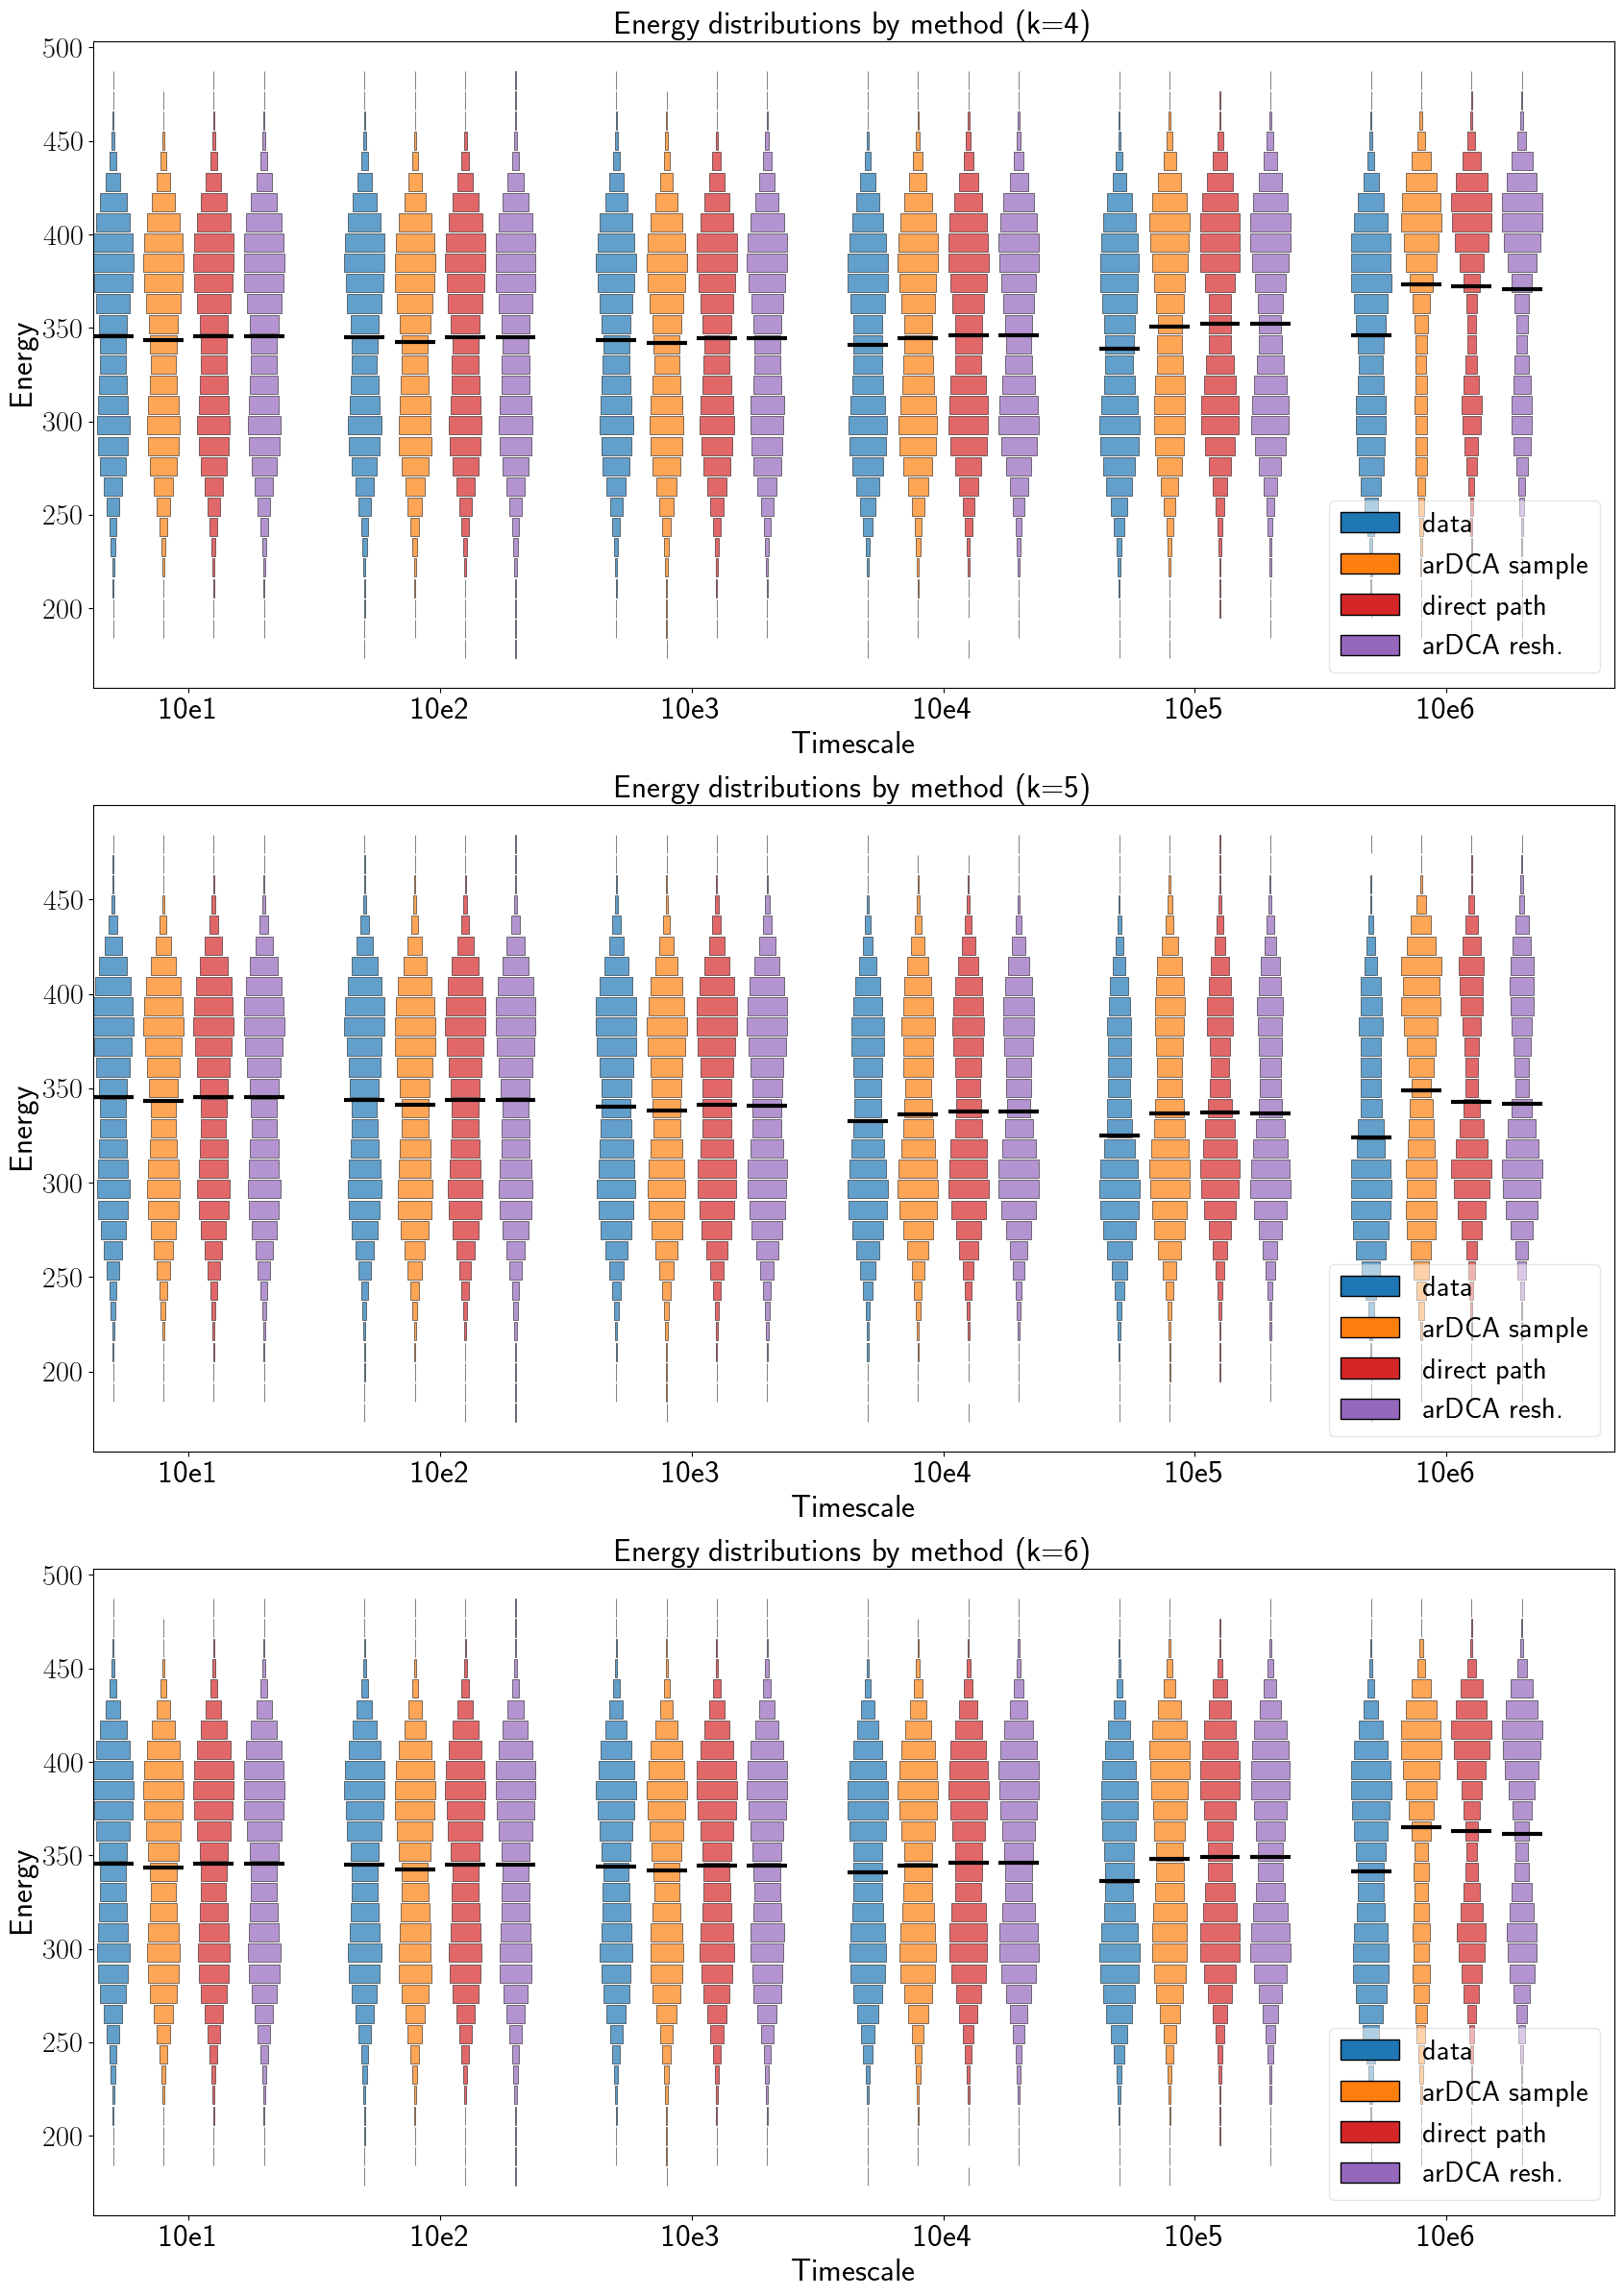

Figura unica salvata: immagini_paper/betalactamase/patience5/ablation/_rJ1e-3_rH1e-5/energy_reshuffled_cluster_top3_subplots.png


In [ ]:
# Plot energy distributions as horizontal histograms in a single 3×1 figure (one panel per k)
print("Creazione plot distribuzione energia (figura unica con 3 subplot)...")
print("=" * 70)

# Define colors for reuse with seaborn tab10 palette
palette = sns.color_palette("tab10")
colors_dict = {
    "data": palette[0],
    "arDCA sample": palette[1],
    "arDCA resh.": palette[4],
    "direct path": palette[3],
}

# Select requested timescales
selected_timescales = ["10e1", "10e2", "10e3", "10e4", "10e5", "10e6"]

n_rows = len(K_values)
fig, axes = plt.subplots(n_rows, 1, figsize=(17, 8 * n_rows), squeeze=False)
axes = axes.flatten()

for row_idx, k in enumerate(K_values):
    ax = axes[row_idx]
    energies_data = energies_data_by_k[k]
    energies_predicted = energies_predicted_by_k[k]
    energies_predicted_reshuffled = energies_predicted_reshuffled_by_k[k]
    energies_predicted_naive = energies_predicted_naive_by_k[k]

    # Prepare data
    methods_data = [
        {"name": "data", "energies": energies_data},
        {"name": "arDCA sample", "energies": energies_predicted},
        {"name": "direct path", "energies": energies_predicted_naive},
        {"name": "arDCA resh.", "energies": energies_predicted_reshuffled},
    ]

    # x positions for the timescales
    positions = np.arange(len(selected_timescales)) * 0.9
    width = 0.18

    # Find the energy range across all data
    all_values = []
    for method_info in methods_data:
        for t in selected_timescales:
            all_values.extend(method_info["energies"][t])
    bins = np.linspace(min(all_values), max(all_values), 30)

    # Plot each method for each timescale
    for i, t in enumerate(selected_timescales):
        for j, method_info in enumerate(methods_data):
            data_vals = method_info["energies"][t]

            # Compute histogram
            counts, bin_edges = np.histogram(data_vals, bins=bins, density=True)

            # Normalise counts so the maximum bar width equals width * 0.8
            max_count = counts.max()
            counts_normalized = counts / max_count * width * 0.8 if max_count > 0 else np.zeros_like(counts)

            # Offset per separare i metodi
            offset = (j - 1.5) * width
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            # Plot barre orizzontali
            for bc, cn in zip(bin_centers, counts_normalized):
                if cn > 0:
                    ax.barh(
                        bc,
                        cn,
                        height=(bin_edges[1] - bin_edges[0]) * 0.9,
                        left=positions[i] + offset - cn / 2,
                        color=colors_dict[method_info["name"]],
                        alpha=0.7,
                        edgecolor="black",
                        linewidth=0.5,
                    )

            # Aggiungi linea orizzontale nera per la media
            mean_val = data_vals.mean()
            ax.hlines(
                mean_val,
                positions[i] + offset - width * 0.4,
                positions[i] + offset + width * 0.4,
                colors="black",
                linewidth=3,
                zorder=10,
            )

    # Crea legenda con i colori dei metodi
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors_dict[method["name"]], edgecolor="black", label=method["name"])
        for method in methods_data
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=22, framealpha=0.5)

    # Etichette assi
    ax.set_xticks(positions)
    ax.set_xticklabels(selected_timescales, fontsize=24)
    ax.set_xlabel("Timescale", fontsize=24, fontweight="bold")
    ax.set_ylabel("Energy", fontsize=24, fontweight="bold")
    ax.set_title(f"Energy distributions by method (k={k})", fontsize=24, fontweight="bold")
    ax.tick_params(axis="y", labelsize=22)

plt.tight_layout()
out_path = output_path + "energy_reshuffled_cluster_top3_subplots.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura unica salvata: {out_path}")
print("=" * 70)

Creazione plot singolo per k selezionato...


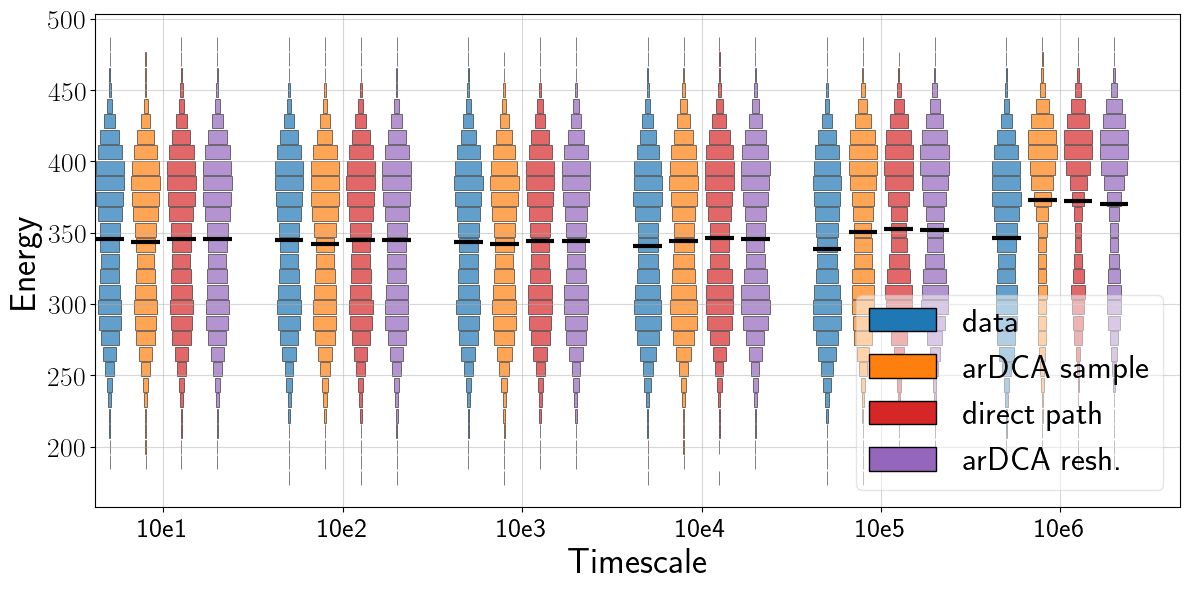

PDF salvato: immagini_paper/betalactamase/patience5/ablation/_rJ1e-3_rH1e-5/energy_reshuffled_cluster_k4_single_subplot.pdf


In [ ]:
# Single-panel energy plot for a manually selected k (saved as PDF)

# =========================
# Parametri modificabili
# =========================
k_to_plot = 4  # <-- Scegli qui il valore di k manualmente

# Font sizes (adjust these to quickly change the figure appearance)
fontsize_title = 24
fontsize_xlabel = 26
fontsize_ylabel = 26
fontsize_xticks = 20
fontsize_yticks = 20
fontsize_legend = 24
fontsize_suptitle = 18

# Altri parametri grafici
figure_width = 12
figure_height = 6
legend_loc = "lower right"
legend_framealpha = 0.5
n_bins = 30
hist_alpha = 0.7
bar_edge_linewidth = 0.5
mean_linewidth = 3
pdf_dpi = 300

print("Creazione plot singolo per k selezionato...")
print("=" * 70)

if k_to_plot not in K_values:
    raise ValueError(f"k_to_plot={k_to_plot} non presente. K disponibili: {K_values}")

# Define colors (consistent with the previous cell)
palette = sns.color_palette("tab10")
colors_dict = {
    "data": palette[0],
    "arDCA sample": palette[1],
    "arDCA resh.": palette[4],
    "direct path": palette[3],
}

selected_timescales = ["10e1", "10e2", "10e3", "10e4", "10e5", "10e6"]

# Retrieve the energy dictionaries for the selected k
energies_data = energies_data_by_k[k_to_plot]
energies_predicted = energies_predicted_by_k[k_to_plot]
energies_predicted_reshuffled = energies_predicted_reshuffled_by_k[k_to_plot]
energies_predicted_naive = energies_predicted_naive_by_k[k_to_plot]

methods_data = [
    {"name": "data", "energies": energies_data},
    {"name": "arDCA sample", "energies": energies_predicted},
    {"name": "direct path", "energies": energies_predicted_naive},
    {"name": "arDCA resh.", "energies": energies_predicted_reshuffled},
]

fig, ax = plt.subplots(1, 1, figsize=(figure_width, figure_height))

positions = np.arange(len(selected_timescales)) * 0.9
width = 0.18

# Global energy range for consistent binning
all_values = []
for method_info in methods_data:
    for t in selected_timescales:
        all_values.extend(method_info["energies"][t])
bins = np.linspace(min(all_values), max(all_values), n_bins)

# Plot compact horizontal histograms per timescale and method
for i, t in enumerate(selected_timescales):
    for j, method_info in enumerate(methods_data):
        data_vals = method_info["energies"][t]
        counts, bin_edges = np.histogram(data_vals, bins=bins, density=True)

        max_count = counts.max()
        counts_normalized = counts / max_count * width * 0.8 if max_count > 0 else np.zeros_like(counts)

        offset = (j - 1.5) * width
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        for bc, cn in zip(bin_centers, counts_normalized):
            if cn > 0:
                ax.barh(
                    bc,
                    cn,
                    height=(bin_edges[1] - bin_edges[0]) * 0.9,
                    left=positions[i] + offset - cn / 2,
                    color=colors_dict[method_info["name"]],
                    alpha=hist_alpha,
                    edgecolor="black",
                    linewidth=bar_edge_linewidth,
                )

        # Linea media energia
        mean_val = data_vals.mean()
        ax.hlines(
            mean_val,
            positions[i] + offset - width * 0.4,
            positions[i] + offset + width * 0.4,
            colors="black",
            linewidth=mean_linewidth,
            zorder=10,
        )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_dict[m["name"]], edgecolor="black", label=m["name"])
    for m in methods_data
]
ax.legend(
    handles=legend_elements,
    loc=legend_loc,
    fontsize=fontsize_legend,
    framealpha=legend_framealpha,
    title=None,
 )

ax.set_xticks(positions)
ax.set_xticklabels(selected_timescales, fontsize=fontsize_xticks)
ax.set_xlabel("Timescale", fontsize=fontsize_xlabel)#, fontweight="bold")
ax.set_ylabel("Energy", fontsize=fontsize_ylabel) #, fontweight="bold")
# ax.set_title(f"Energy distributions by method (k={k_to_plot})", fontsize=fontsize_title, fontweight="bold")
ax.tick_params(axis="y", labelsize=fontsize_yticks)
ax.grid(True, alpha=0.5)

# plt.suptitle("Single-k Energy Distribution", fontsize=fontsize_suptitle, y=1.02)
plt.tight_layout()

out_path_pdf = output_path + f"energy_reshuffled_cluster_k{k_to_plot}_single_subplot.pdf"
plt.savefig(out_path_pdf, dpi=pdf_dpi, bbox_inches="tight")
plt.show()

print(f"PDF salvato: {out_path_pdf}")
print("=" * 70)

Creazione plot delle medie energie (figura unica con 3 subplot)...


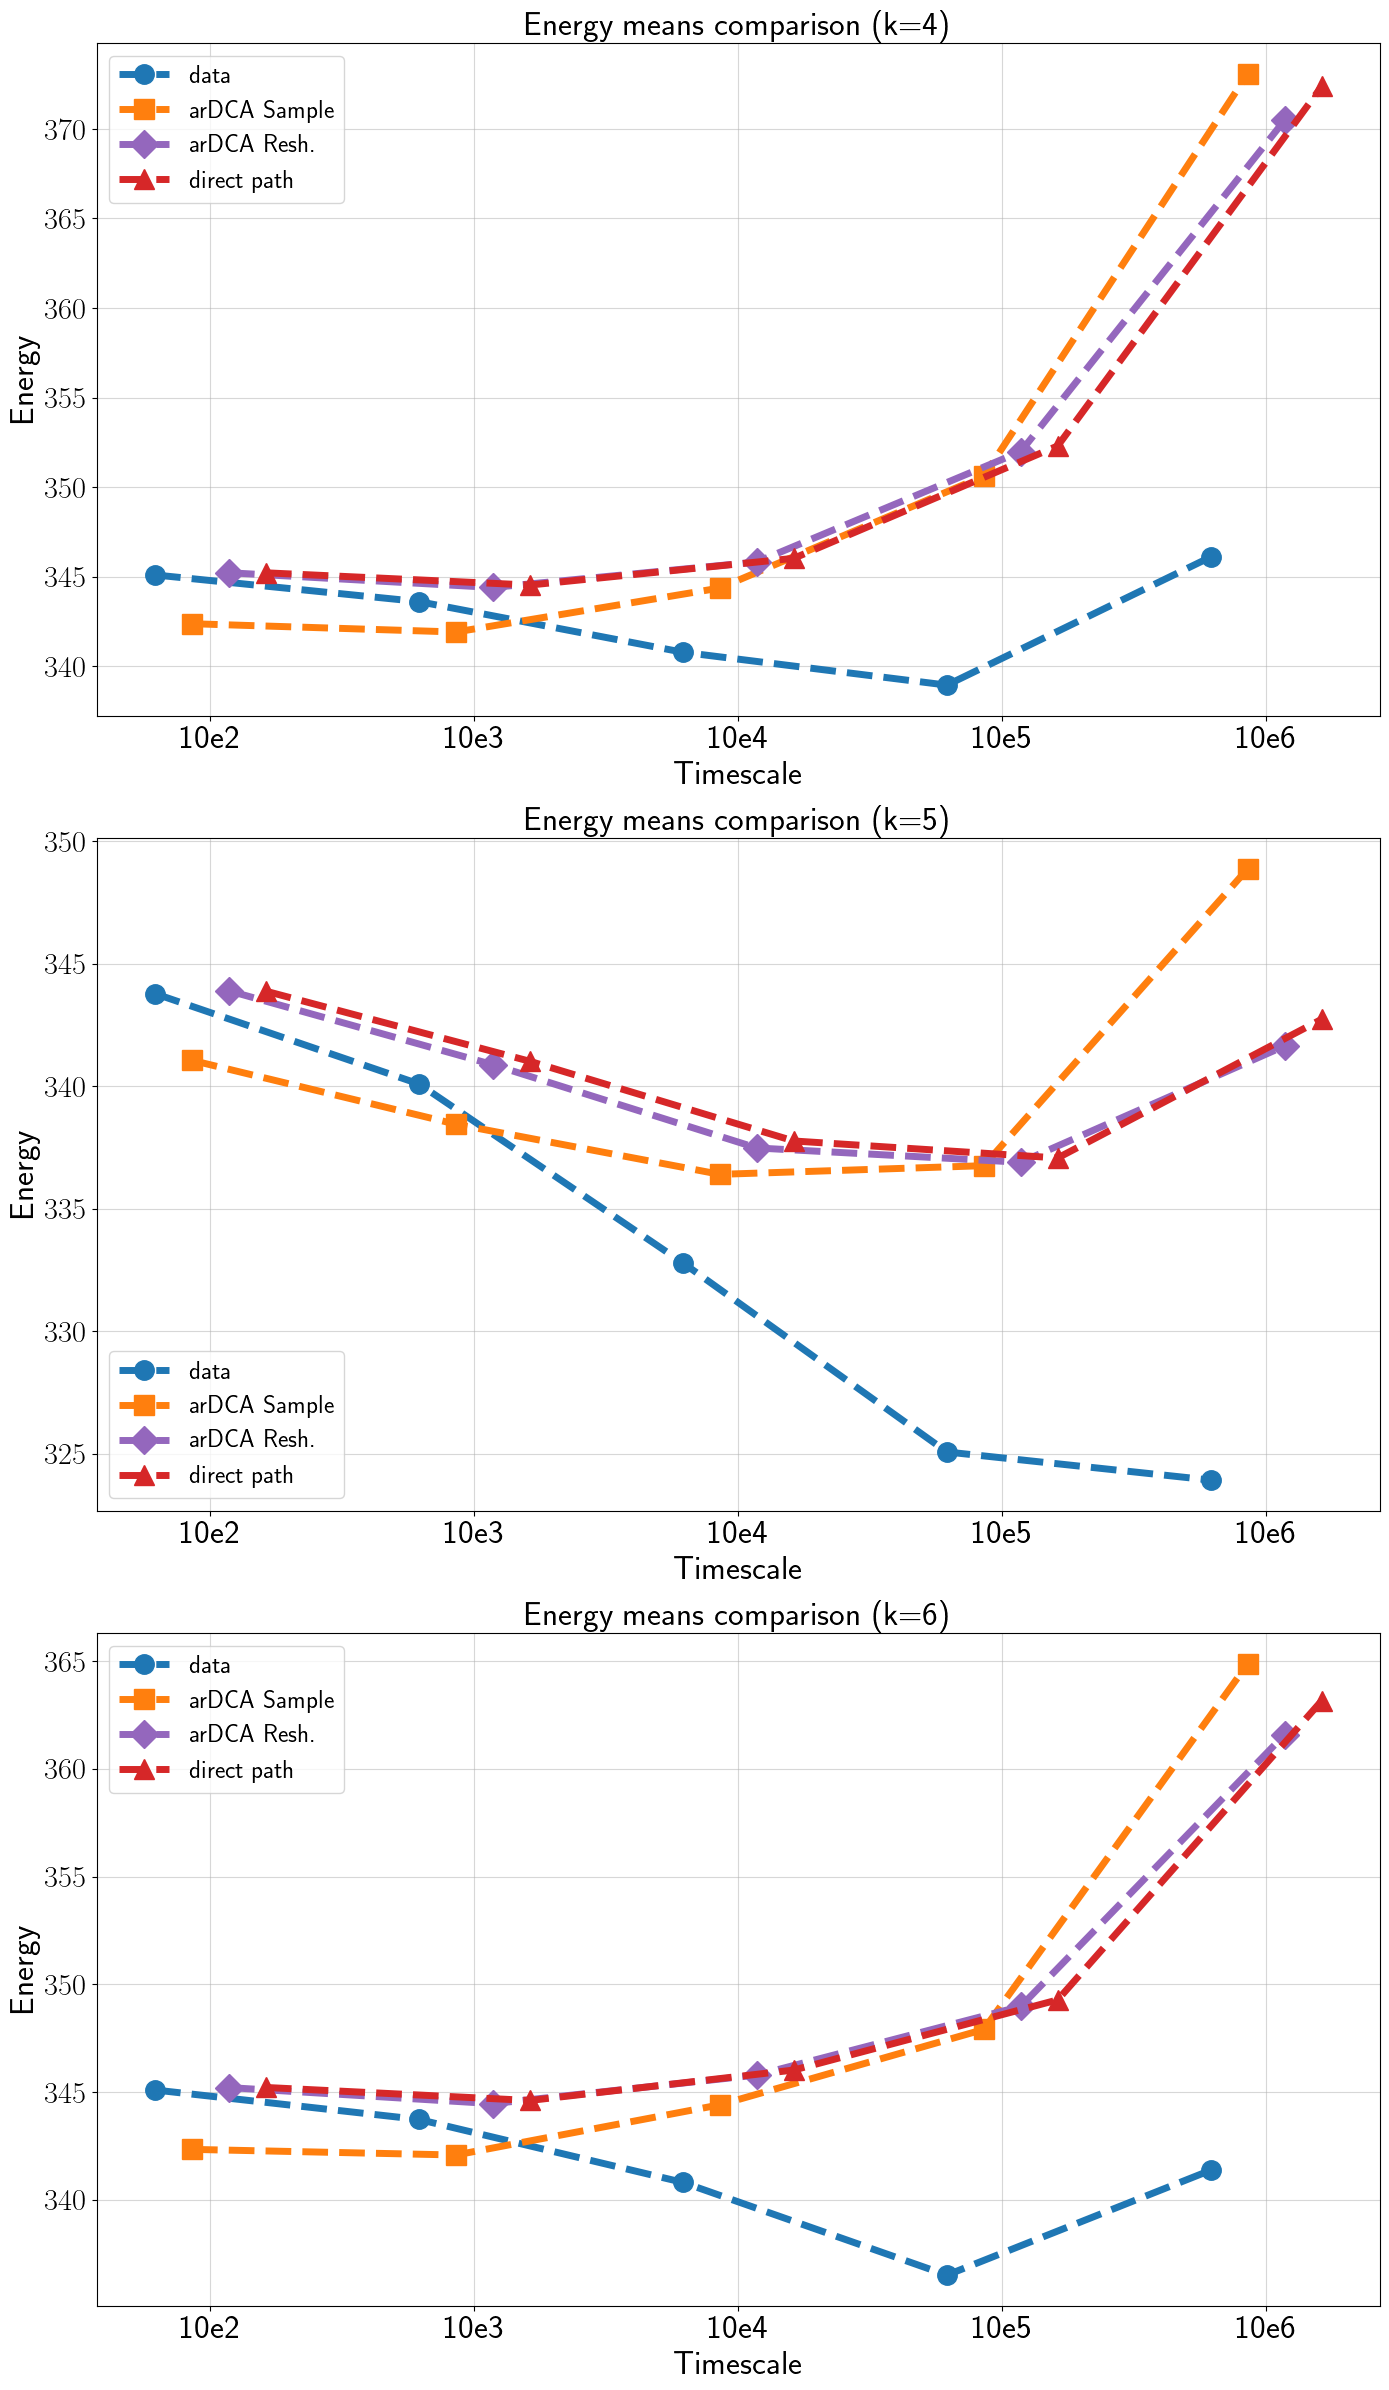

Figura unica salvata: immagini_paper/betalactamase/patience5/ablation/_rJ1e-3_rH1e-5/energy_means_comparison_top3_subplots.png


In [ ]:
# Plot energy means in a single 3×1 figure (one panel per k)
print("Creazione plot delle medie energie (figura unica con 3 subplot)...")
print("=" * 70)

# Prepare colors
colors_dict = {
    "data": "C0",
    "arDCA Sample": "C1",
    "arDCA Resh.": "C4",
    "direct path": "C3",
}

# Select timescales
selected_timescales = ["10e2", "10e3", "10e4", "10e5", "10e6"]

n_rows = len(K_values)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 8 * n_rows), squeeze=False)
axes = axes.flatten()

for row_idx, k in enumerate(K_values):
    ax = axes[row_idx]
    energies_data = energies_data_by_k[k]
    energies_predicted = energies_predicted_by_k[k]
    energies_predicted_reshuffled = energies_predicted_reshuffled_by_k[k]
    energies_predicted_naive = energies_predicted_naive_by_k[k]

    x_pos = np.arange(len(selected_timescales))
    width = 0.1

    # Compute means for each method and timescale
    means_data = [energies_data[t].mean() for t in selected_timescales]
    means_arDCA_sample = [energies_predicted[t].mean() for t in selected_timescales]
    means_arDCA_resh = [energies_predicted_reshuffled[t].mean() for t in selected_timescales]
    means_direct_path = [energies_predicted_naive[t].mean() for t in selected_timescales]

    # Plot means as lines
    ax.plot(
        x_pos - 2.1 * width,
        means_data,
        "o--",
        linewidth=5,
        markersize=14,
        label="data",
        color=colors_dict["data"],
    )
    ax.plot(
        x_pos - 0.7 * width,
        means_arDCA_sample,
        "s--",
        linewidth=5,
        markersize=14,
        label="arDCA Sample",
        color=colors_dict["arDCA Sample"],
    )
    ax.plot(
        x_pos + 0.7 * width,
        means_arDCA_resh,
        "D--",
        linewidth=5,
        markersize=14,
        label="arDCA Resh.",
        color=colors_dict["arDCA Resh."],
    )
    ax.plot(
        x_pos + 2.1 * width,
        means_direct_path,
        "^--",
        linewidth=5,
        markersize=14,
        label="direct path",
        color=colors_dict["direct path"],
    )

    # x-axis labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(selected_timescales, fontsize=24)
    ax.set_xlabel("Timescale", fontsize=24, fontweight="bold")
    ax.set_ylabel("Energy", fontsize=24, fontweight="bold")
    ax.set_title(f"Energy means comparison (k={k})", fontsize=24, fontweight="bold")
    ax.tick_params(axis="y", labelsize=22)
    ax.legend(fontsize=18, loc="best")
    ax.grid(True, alpha=0.5)

plt.tight_layout()
out_path = output_path + "energy_means_comparison_top3_subplots.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura unica salvata: {out_path}")
print("=" * 70)